# Reionisation observables from the electron power spectrum

In [1]:
import time
import matplotlib.pyplot as plt
from matplotlib import rc, colors
import numpy as np
from astropy import cosmology, units, constants
# import healpy as hp
import os
from scipy.interpolate import interp1d
from tqdm import tqdm

In [2]:
from theory import Pee_model
from utils import *

In [3]:
rc("font", **{"family": "serif", "serif": ["times new roman"], "size": 18})
rc("text", usetex=True)
rc("axes", linewidth=1.5)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
CL = 68
percentile1 = (100.-CL)/2.
percentile2 = CL+(100.-CL)/2.

In [6]:
ells = np.arange(50, 10000, step=250)

In [7]:
cos = cosmology.Planck18

## Consistent reionisation observables: power spectra

The `Pee_model` class allows you to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum, all following a consistent reionsation model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020.

In [8]:
model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=True, run_camb=True)

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0603
Running CAMB...


Text(0.5, 1.0, '$z=7.0$')

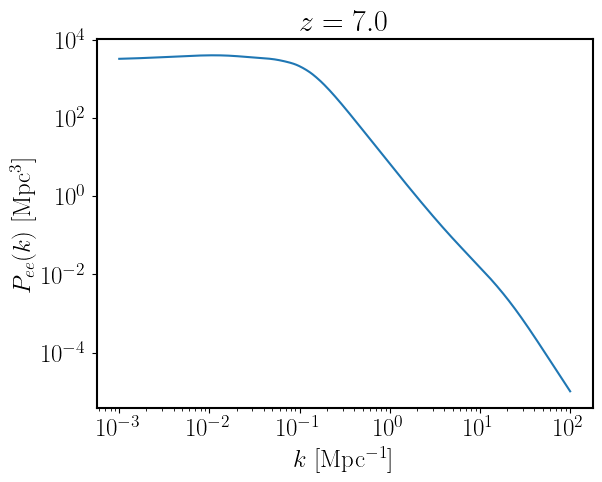

In [9]:
klog = np.logspace(-3, 2, 500)

plt.figure()
plt.loglog(klog, model.Pee(klog, model.zre_h))
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
plt.title(rf'$z={model.zre_h:.1f}$')

### Reionisation history

5.5 7.0


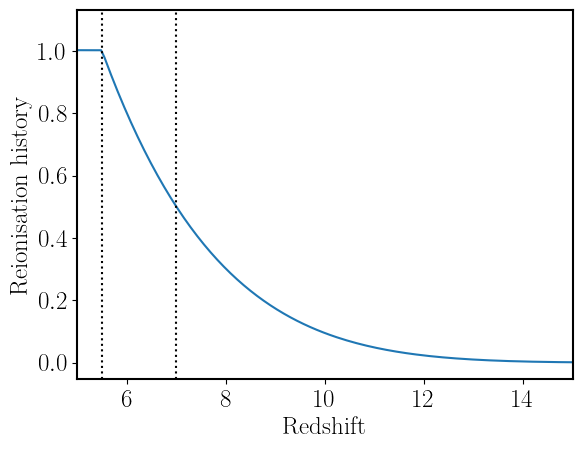

In [10]:
z = np.linspace(0, 20, 300)
print(model.zend_h, model.zre_h)
plt.figure()
plt.plot(z, model.xe(z)/1.08)
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')
plt.xlim(5, 15)
plt.axvline(model.zend_h, color='k', ls=':')
plt.axvline(model.zre_h, color='k', ls=':')

### kSZ power spectrum

To compute the kSZ power spectrum, use the `get_ksz` method. 
The following will output the kSZ power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [11]:
ksz_file = 'data/ref_ksz.txt'
if os.path.exists(ksz_file):
    ksz_ps = np.loadtxt(ksz_file, unpack=True)[1:].T
else:
    t0 = time.time()
    ksz_ps = model.get_ksz(ells=ells, signal='both', Dells=True)
    t1 = time.time()
    print(f'Computation took {t1-t0:.1f} seconds.')
    np.savetxt(ksz_file, np.c_[ells, ksz_ps], header='ells, Dells ksz')

In [12]:
i3000 = np.argmin(np.abs(3000-ells))
print(f'At l=3000, [atchy power = {ksz_ps[i3000, 0]:.1f} uK2, late-time power = {ksz_ps[i3000, 1]:.1f} uK2')

At l=3000, [atchy power = 1.2 uK2, late-time power = 3.1 uK2


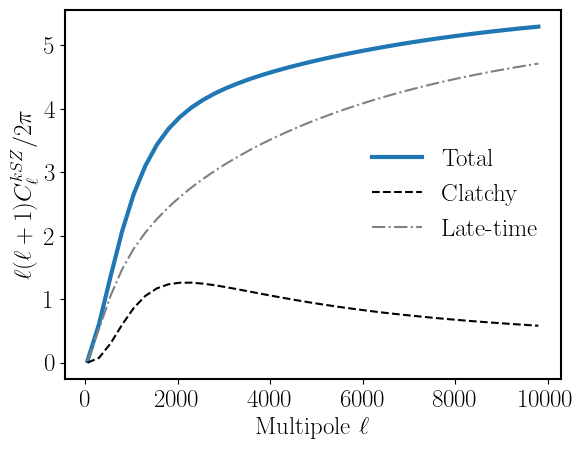

In [13]:
plt.figure()
plt.plot(ells, np.sum(ksz_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, ksz_ps[:, 0], label='Clatchy', ls='--', color='k')
plt.plot(ells, ksz_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### $\tau$ power spectrum

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [14]:
tau_file = 'data/ref_tau.txt'
if os.path.exists(tau_file):
    tau_ps = np.loadtxt(tau_file, unpack=True)[1:].T
else:
    t0 = time.time()
    tau_ps = model.get_tau(ells=ells, signal='both', Dells=True)
    t1 = time.time()
    print(f'Computation took {t1-t0:.1f} seconds.')
    np.savetxt(tau_file, np.c_[ells, tau_ps], header='ells, Dells tau')

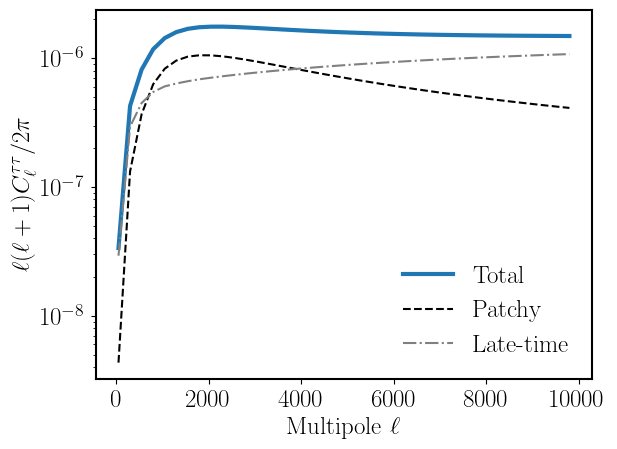

In [15]:
plt.figure()
plt.semilogy(ells, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### 21cm power spectrum

To compute the 21cm power spectrum, use the `get_p21(k,z)` method.

In [16]:
zarr = np.linspace(5., 10, 20)
karr = np.logspace(-4, 2, 100)

ps_21 = model.get_p21(karr, zarr[:, None], mK=True, log=False, pk_units=True)

Text(0, 0.5, 'Reionisation history')

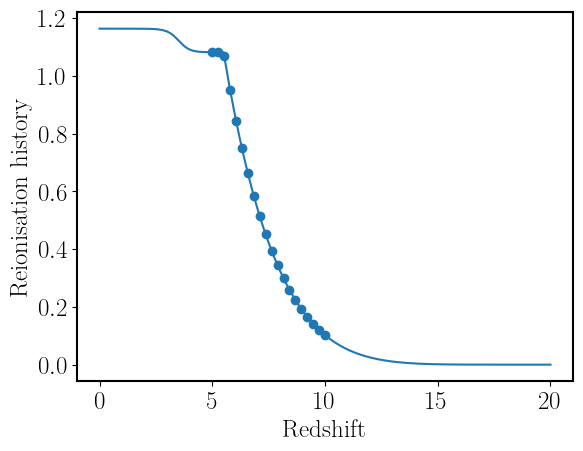

In [17]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, model.xe(z))
plt.scatter(zarr, model.xe(zarr))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

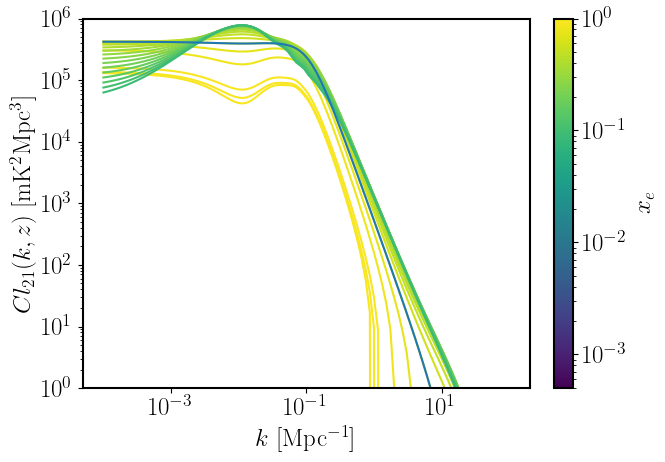

In [18]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

fig, ax = plt.subplots()
for iz, z in enumerate(zarr):
    ax.loglog(karr, ps_21[iz], color=cmap(norm(model.xe(z)[0]/model.f)))
ax.plot(karr, ps_21[5])
ax.set_ylim(1e0, 1e6)
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$Cl_{21}(k, z)$ [mK$^2$Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

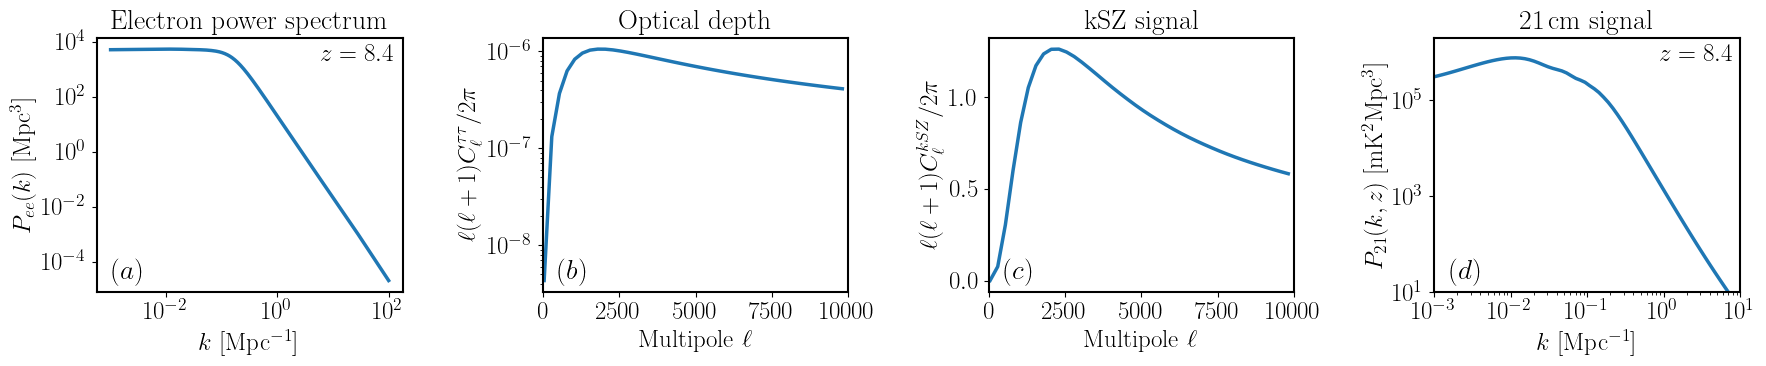

In [19]:
zref = 8.4
props = dict(boxstyle="round", facecolor="white", alpha=0.5)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
# pee
axes[0].loglog(klog, model.Pee(klog, zref), lw=2.5)
axes[0].set_xlabel(r'$k$ [Mpc$^{-1}$]')
axes[0].set_ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
axes[0].text(6, 2000, rf'$z={zref:.1f}$')#, bbox=props)
# tau
axes[1].semilogy(ells, tau_ps[:, 0], ls='-', color='C0', lw=2.5)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# axes[1].set_ylim(bottom=1e-5)
axes[1].set_xlim(0, 10000)

# ksz
axes[2].plot(ells, ksz_ps[:, 0], lw=2.5)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
axes[2].set_xlim(0, 10000)

# 21cm ps
axes[3].loglog(karr, model.get_p21(karr, zref, mK=True, log=False, pk_units=True), lw=2.5)
axes[3].set_ylim(bottom=1e0)
axes[3].set_xlabel(r'$k$ [Mpc$^{-1}]$')
axes[3].set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
axes[3].set_xlim(1e-3, 10)
axes[3].set_ylim(10, 2e6)
axes[3].text(.9, 6.5e5, rf'$z={zref:.1f}$')#, bbox=props)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', '21\,cm signal'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].text(0.05, 0.05, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20)
fig.tight_layout()
# fig.savefig('model2observables_ps.pdf', dpi=220)

### Primary power spectra

The class also computes primary power spectra:

In [20]:
CMB_Cells = model.get_primary_spectra(ells=np.linspace(1, 500))

 Computing CMB power spectra...


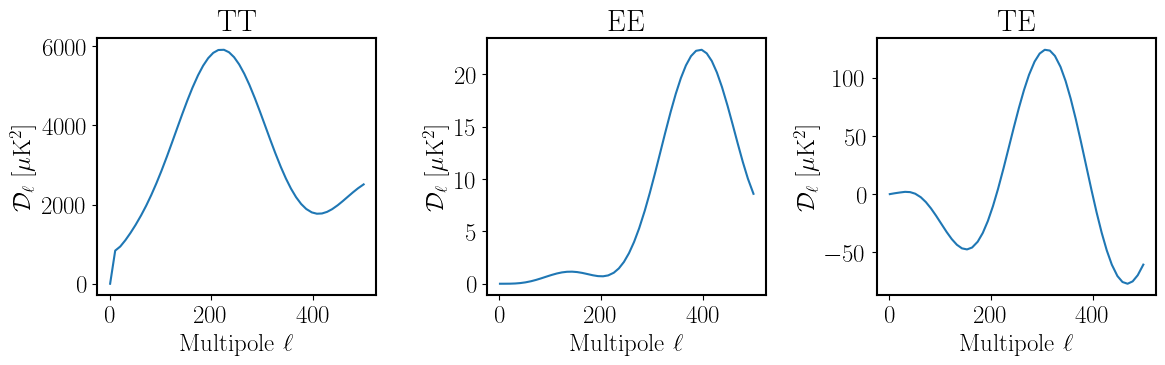

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for u, (ax, label) in enumerate(zip(axes,
                                   [ 'TT', 'EE', 'TE'])):
    ax.plot(CMB_Cells[:, 0], CMB_Cells[:, u+1])
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
    ax.set_title(label)
    ax.set_xlabel(r'Multipole $\ell$')
fig.tight_layout()

## Analytical cross-spectra

In [22]:
Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=0.)
print(Dl_tau_21.unit)

K


20it [00:00, 21.51it/s]


Text(0.5, 1.0, '$\\Delta \\nu=0.0$MHz')

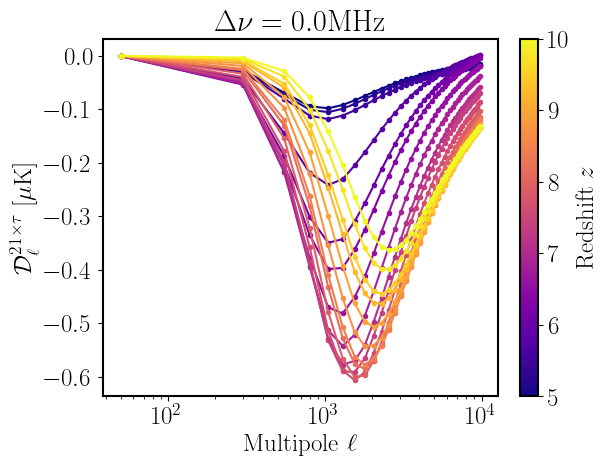

In [23]:
cmap = colormaps['plasma']
norm = colors.Normalize(vmin=np.min(zarr), vmax=np.max(zarr)) #can also use LogNorm
dnu = 0.

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={dnu:.1f}$MHz')

20it [00:00, 21.68it/s]


Text(0.5, 1.0, '$\\Delta \\nu=10.0$MHz')

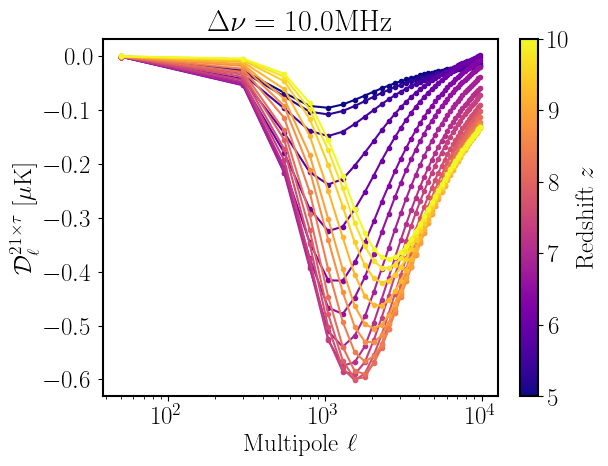

In [24]:
dnu = 10.  # MHz

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={dnu:.1f}$MHz')

9it [00:00, 20.88it/s]


Text(0.5, 1.0, '$z=7.0$')

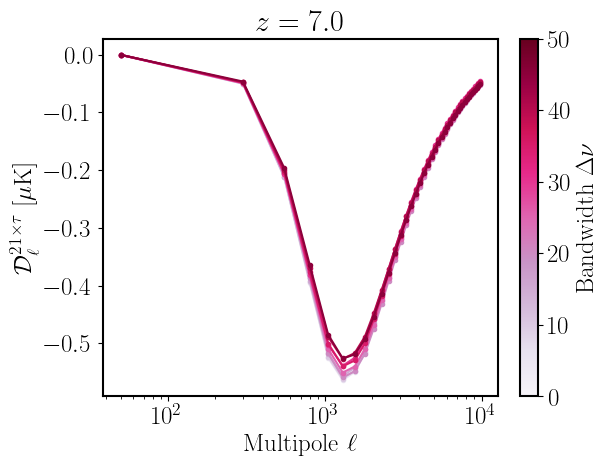

In [25]:
cmap = colormaps['PuRd']
norm = colors.Normalize(vmin=0, vmax=50) #can also use LogNorm
z = model.zre_h
fig, ax = plt.subplots()
for i, dnu in tqdm(enumerate(np.arange(5, 50, step=5.))):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$\Delta\nu={dnu:.1f}MHz$', color=cmap(norm(dnu)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Bandwidth $\Delta\nu$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$z={model.zre_h:.1f}$')

## Make Gaussian boxes from power spectra

From these power spectra, we can generate Gaussian random boxes (with corresponding power spectrum). We work in the flat-sky approximation and identify the angular power spectrum with the Fourier power spectrum, following $k \sim 2\ell / d_c(z)$.

In [26]:
from simulations import gaussian_box_from_ps, gaussian_box_from_cl

In [27]:
ndim = 3
N = 512
fov = 5. * units.deg

In [28]:
size = tuple([N for i in range(ndim)])
phases = np.random.random(size) * 2. * np.pi

In [29]:
iz = 8
L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
print(zarr[iz], model.xe(zarr[iz]), L21)

7.105263157894736 [0.51376596] 772.6277414014246


6.052631578947368 [0.84538684]


Text(0, 0.5, '$\\mathcal{D}_\\ell$ [$\\mu$K$^2$]')

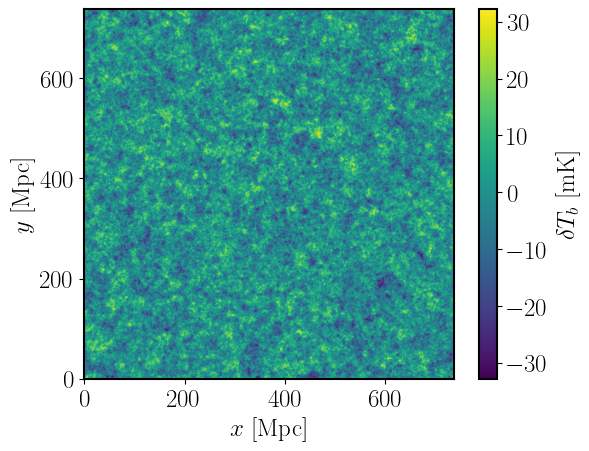

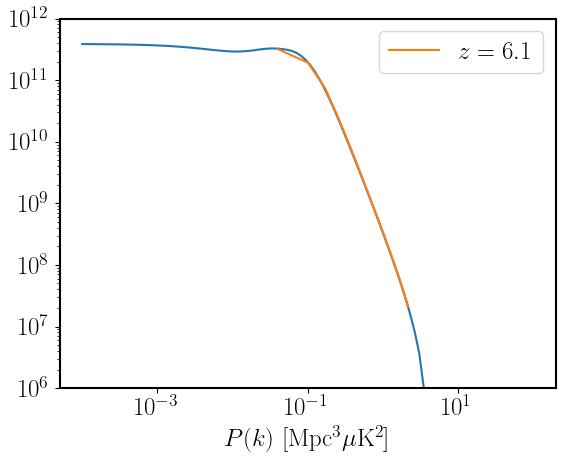

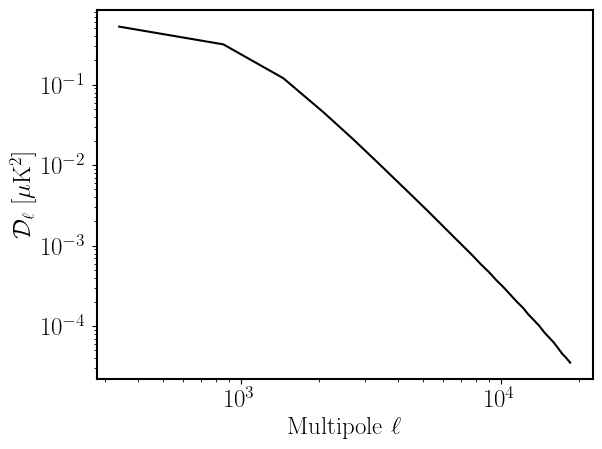

In [30]:
iz = 4
L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
print(zarr[iz], model.xe(zarr[iz]))
pk_array = np.c_[karr, ps_21[iz] * 1e6].T   # muK2
box_21 = gaussian_box_from_ps(N, L21, pk_array, ndim=ndim, phases=phases)

fig, ax = plot_field(box_21/1000, L21, label=r'$\delta T_b$ [mK]')
ks, pks, es = compute_ps1d(box_21, L21)

plt.figure()
plt.loglog(pk_array[0], pk_array[1])
plt.plot(ks, pks, label=rf'$z={zarr[iz]:.1f}$')
plt.ylim(1e6, 1e12)
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.xlabel(r'$P(k)$ [Mpc$^3 \mu$K$^2$]')
plt.legend()

ls, cls, erls = compute_cl_from_box(box_21, fov.to(units.rad).value, nbins=30)
# print(cls)
plt.figure()
# plt.plot(pk_array[0], pk_array[1])
plt.loglog(ls[cls>0.], cls[cls>0.], color='k')
# ls, cls, erls = compute_ps1d(cmb_box, fov2.to(units.rad).value * cos.comoving_distance(zobs_cmb).value, nbins=20)
# plt.plot(ls[cls>0.]*cos.comoving_distance(zobs_cmb).value, cls[cls>0.]/1e7)
# plt.xlim(0, 1000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
# print(ls)


In [31]:
# integrated 21cm signal
dTb_maps = np.zeros((zarr.size, N, N, N), dtype=float)
for iz in tqdm(range(zarr.size)):
    L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
    pk_array = np.c_[karr, ps_21[iz] * 1e6].T  # muK2
    dTb_maps[iz] = gaussian_box_from_ps(N, L21, pk_array, ndim=ndim, phases=phases)

100%|██████████| 20/20 [10:26<00:00, 31.34s/it]


In [32]:
int_21cm = np.trapz(np.array(dTb_maps), zarr, axis=0)

Text(0.5, 1.0, 'Integrated 21cm signal')

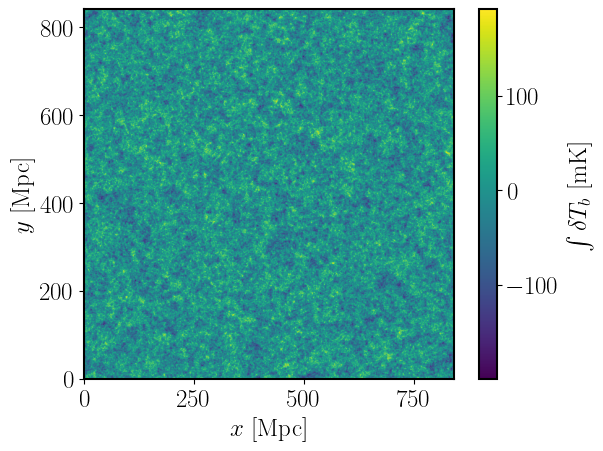

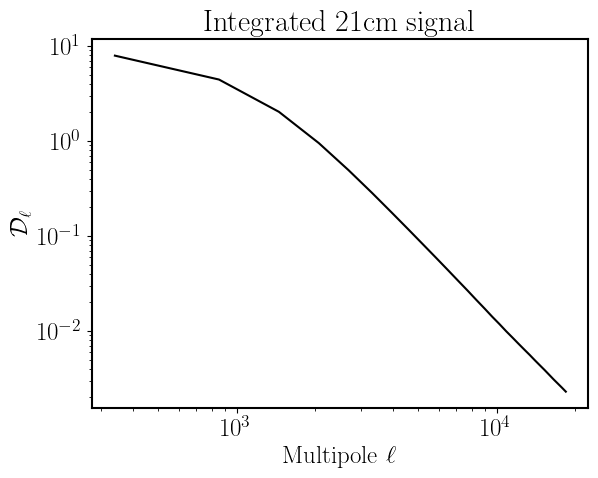

In [33]:
fig, ax = plot_field(int_21cm/1000, L21, label=r'$\int \delta T_b$ [mK]')

ls, cls, erls = compute_cl_from_box(int_21cm, fov.to(units.rad).value, nbins=30)
plt.figure()
plt.loglog(ls[cls>0.], cls[cls>0.], color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$')
plt.title('Integrated 21cm signal')

0.4285714285714286 0.09765625 deg 0.05285483163838915
2.781108676686017e-14


Text(0, 0.5, '$P(k)$ [Mpc$^3$]')

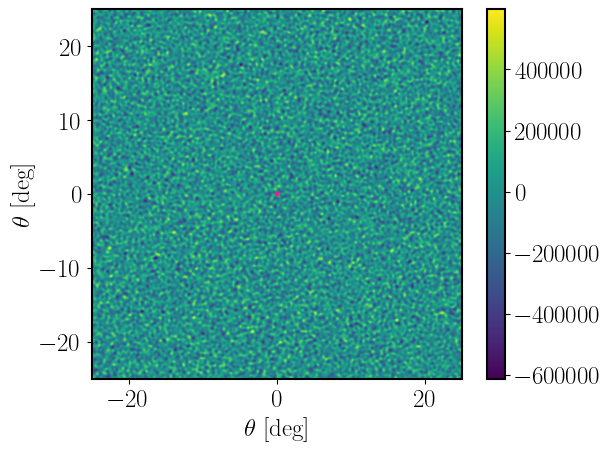

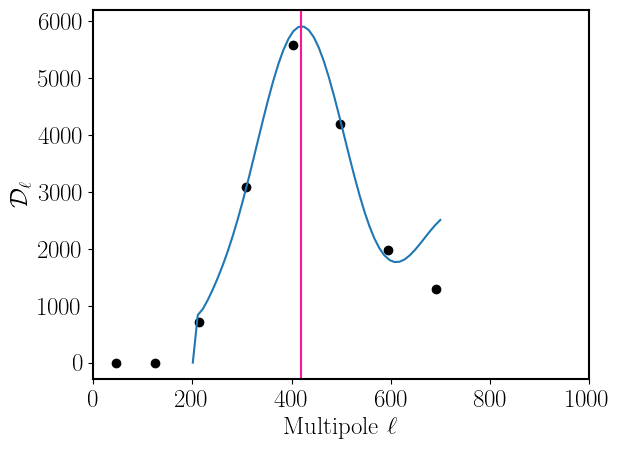

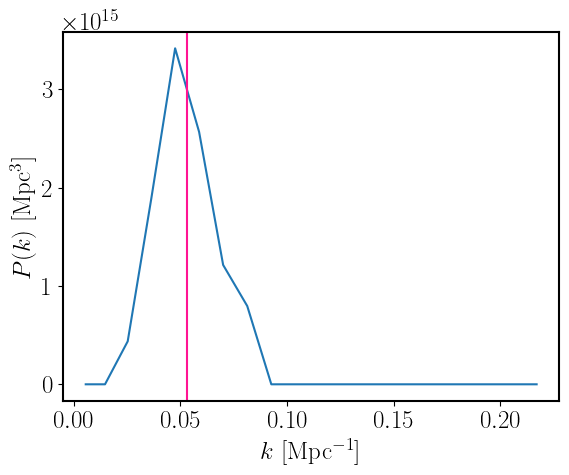

In [34]:
fov2 = 10.*fov
zobs_cmb = 5.

ref_multipole = 220. +200.
ref_theta = (np.pi/ref_multipole)*(180./np.pi)
ref_kx = ref_multipole/cos.comoving_distance(zobs_cmb).value
print(ref_theta, fov2.to(units.deg)/N, ref_kx)

pk_array = np.copy(CMB_Cells[:, :2].T)
pk_array[0] += 200
cmb_box = gaussian_box_from_cl(N, fov2.to(units.rad).value, pk_array, ndim=3)

# physical box
fig, ax = plot_field_theta(cmb_box, fov2.to(units.deg).value,)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,#fov2.to(units.deg).value/N,#ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)
print(np.mean(cmb_box))

# angular power spectrum
ls, cls, erls = compute_cl_from_box(cmb_box, fov2.to(units.rad).value, nbins=20)
plt.figure()
plt.plot(pk_array[0], pk_array[1])
plt.axvline(ref_multipole, color='deeppink')
plt.scatter(ls[cls>0.], cls[cls>0.], color='k')
# ls, cls, erls = compute_ps1d(cmb_box, fov2.to(units.rad).value * cos.comoving_distance(zobs_cmb).value, nbins=20)
# plt.plot(ls[cls>0.]*cos.comoving_distance(zobs_cmb).value, cls[cls>0.]/1e7)
plt.xlim(0, 1000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$')
# print(ls)

# cartesian power spectrum
ks, pks, err_pks = compute_ps1d(cmb_box, np.tan(fov2.to(units.rad).value/2.) *2. *  cos.comoving_distance(zobs_cmb).value, nbins=20)
plt.figure()
plt.plot(ks, pks)
plt.axvline(ref_kx, color='deeppink')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P(k)$ [Mpc$^3$]')


(0.0, 10000.0)

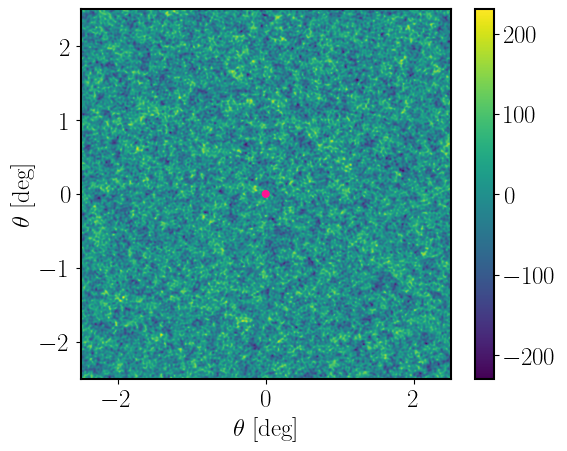

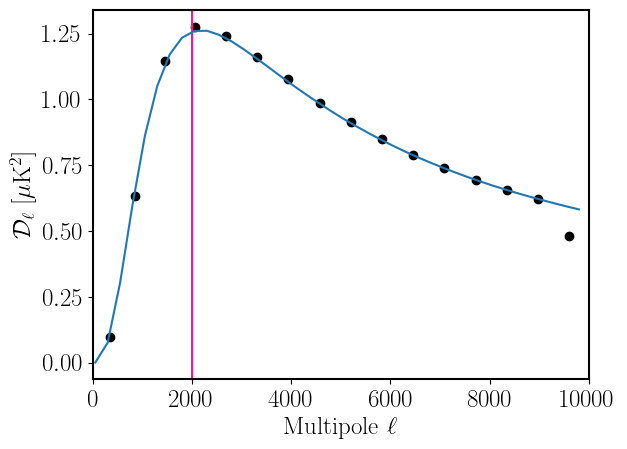

In [35]:
pk_array = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

ksz_box = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array, ndim=ndim, phases=phases)
fig, ax = plot_field_theta(ksz_box, fov.to(units.deg).value)
ref_multipole = 2000.
ref_theta = (np.pi/ref_multipole)*(180./np.pi)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)

ls, cls, erls = compute_cl_from_box(ksz_box, fov.to(units.rad).value)

plt.figure()
plt.axvline(ref_multipole, color='deeppink')
plt.plot(pk_array[0], pk_array[0]*(pk_array[0]+1.)*pk_array[1]/2./np.pi)
plt.scatter(ls, ls*(ls+1.)*cls/2./np.pi, color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 10000)

(0.0, 10000.0)

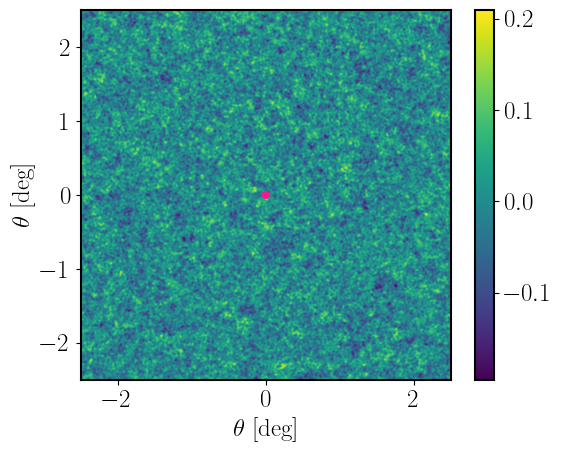

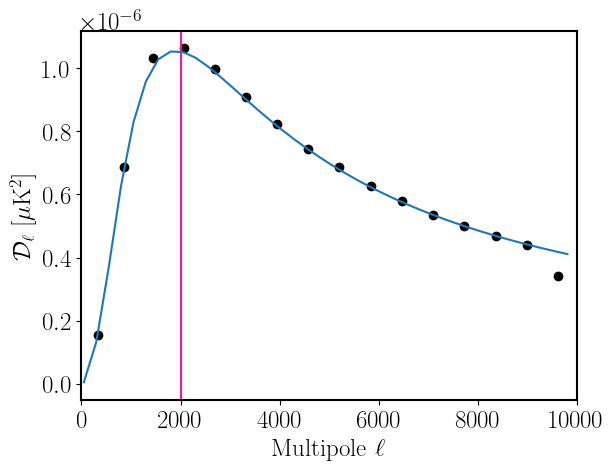

In [36]:
# pk_array = np.c_[ells, (tau_ps[:, 0]+tau_ps[:, 1])/ells/(ells + 1)*2.0*np.pi/(model.T_cmb * 1e6) ** 2].T
pk_array = np.c_[ells, tau_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

tau_box = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array, ndim=ndim, phases=phases)
fig, ax = plot_field_theta(tau_box, fov.to(units.deg).value)
# ref_theta = (np.pi/3000.)*(180./np.pi)
circle = plt.Circle(
    (0, 0),
    radius=ref_theta/2.,
    color='deeppink',
    fill=True,
    lw=1.0,
)
ax.add_patch(circle)

ls, cls, erls = compute_cl_from_box(tau_box, fov.to(units.rad).value)

plt.figure()
plt.axvline(ref_multipole, color='deeppink')
plt.plot(pk_array[0], pk_array[0]*(pk_array[0]+1.)*pk_array[1]/2./np.pi)
plt.scatter(ls, ls*(ls+1.)*cls/2./np.pi, color='k')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 10000)

## Compute cross-spectra

In [37]:
# k, P21_tau, P21_tau_err = compute_cross_spectrum(tau_box, box_21, L, nbins=30)
# k, P21_ksz, P21_ksz_erer = compute_cross_spectrum(ksz_box, box_21, L, nbins=30)
# k, Ptau_ksz, Ptau_ksz_err = compute_cross_spectrum(ksz_box, tau_box, L, nbins=30)

l, Cl21_tau, Cl21_tau_err = compute_cross_angular_spectrum(tau_box, box_21, fov.to(units.rad).value, nbins=30)
l, Cl21_ksz, Cl21_ksz_err = compute_cross_angular_spectrum(ksz_box, box_21, fov.to(units.rad).value, nbins=30)
l, Cltau_ksz, Cltau_ksz_err = compute_cross_angular_spectrum(ksz_box, tau_box, fov.to(units.rad).value, nbins=30)

In [38]:
l, Cl_int21_tau, Cl_int21_tau_err = compute_cross_angular_spectrum(tau_box, int_21cm, fov.to(units.rad).value, nbins=30)
l, Cl_int21_ksz, Cl_int21_ksz_err = compute_cross_angular_spectrum(ksz_box, int_21cm, fov.to(units.rad).value, nbins=30)

In [39]:
l, Cl_int21_int21, Cl_int21_int21_err = compute_cross_angular_spectrum(int_21cm, int_21cm, fov.to(units.rad).value, nbins=30)

In [40]:
l, Cl21_ksz2, Cl21_ksz2_err = compute_cross_angular_spectrum(ksz_box**2, box_21, fov.to(units.rad).value, nbins=30)

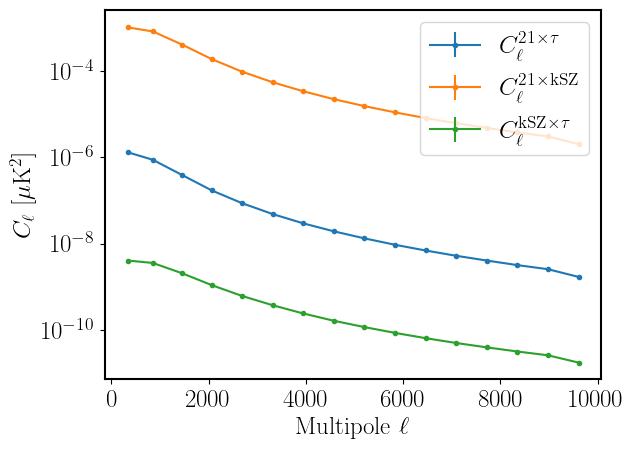

In [41]:
fig, ax = plt.subplots()
for cls, cls_err, label in zip(
    [Cl21_tau, Cl21_ksz, Cltau_ksz], 
    [Cl21_tau_err, Cl21_ksz_err, Cltau_ksz_err], 
    [r'$C_\ell^{21\times \tau}$', r'$C_\ell^{21\times \mathrm{kSZ}}$', r'$C_\ell^{\mathrm{kSZ}\times \tau}$']):
    m = cls != 0.
    ax.errorbar(l[m], cls[m], yerr=cls_err[m], label=label, marker='.')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$  [$\mu$K$^2$]')
ax.legend()
# ax.set_xscale('log')
ax.set_yscale('log')                                    

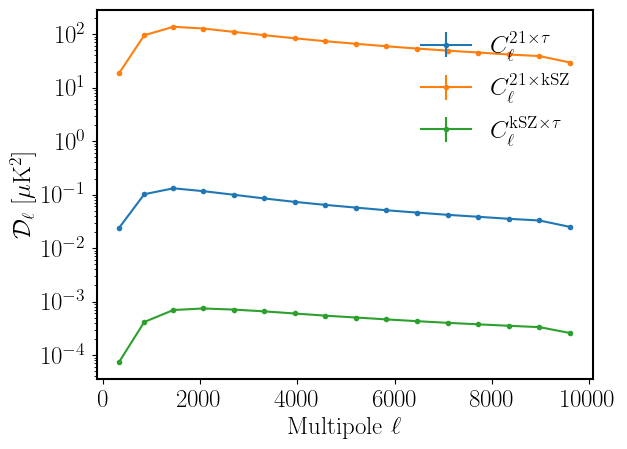

In [42]:
fig, ax = plt.subplots()
for cls, cls_err, label in zip(
    [Cl21_tau, Cl21_ksz, Cltau_ksz], 
    [Cl21_tau_err, Cl21_ksz_err, Cltau_ksz_err], 
    [r'$C_\ell^{21\times \tau}$', r'$C_\ell^{21\times \mathrm{kSZ}}$', r'$C_\ell^{\mathrm{kSZ}\times \tau}$']):
    m = cls != 0.
    ax.errorbar(
        l[m], l[m] * (l[m]+1.) * cls[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * cls_err[m] / 2./np.pi ,
        label=label, marker='.')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
ax.legend(frameon=False)
ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     

129.0909090909091 236.66666666666666 107.57575757575756


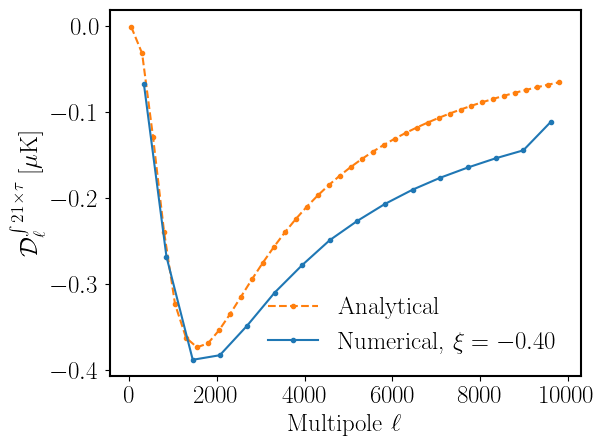

In [43]:
nu_min = (1420.) / (1. + zarr.max())
nu_max = (1420.) / (1. + zarr.min())
print(nu_min, nu_max, nu_max-nu_min)
bandwidth = nu_max-nu_min
xi = -.4

pk_array = np.c_[ells, tau_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T
tau_box_shift = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array, ndim=ndim, phases=phases + (xi - 1.)/2. * np.pi)
ls, cls, cls_err = compute_cross_angular_spectrum(tau_box_shift, int_21cm, fov.to(units.rad).value, nbins=30)

fig, ax = plt.subplots()
m = cls != 0.
ax.errorbar(ls[m], ls[m] * (ls[m]+1.) * cls[m]/2./np.pi, label=rf'Numerical, $\xi={xi:.2f}$', marker='.')
ax.plot(ells, model.get_tau_21_cross(np.mean(zarr), ells, Dells=True, delta_nu=bandwidth).to(units.uK), marker='.', ls='--', label='Analytical')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{\int21\times \tau}$ [$\mu$K]')
ax.legend(frameon=False)
# ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     
fig.tight_layout()
fig.savefig('figures/tau_int21_num_vs_analytic.pdf', dpi=220)

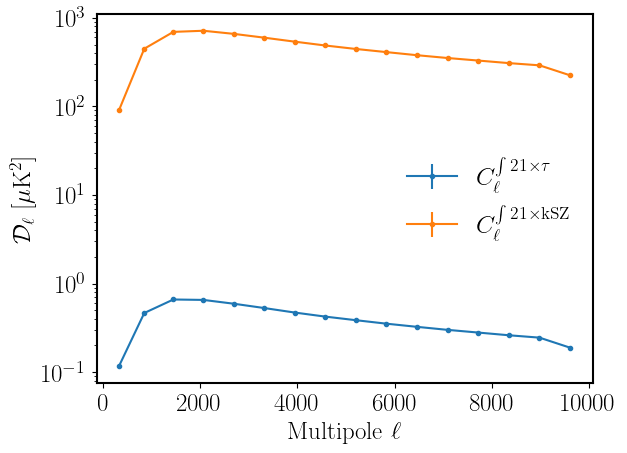

In [44]:
fig, ax = plt.subplots()
for cls, cls_err, label in zip(
    [Cl_int21_tau, Cl_int21_ksz], 
    [Cl_int21_tau_err, Cl_int21_ksz_err], 
    [r'$C_\ell^{\int21\times \tau}$', r'$C_\ell^{\int21\times \mathrm{kSZ}}$']):
    m = cls != 0.
    ax.errorbar(
        l[m], l[m] * (l[m]+1.) * cls[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * cls_err[m] / 2./np.pi,
        label=label, marker='.')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
ax.legend(frameon=False)
ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     

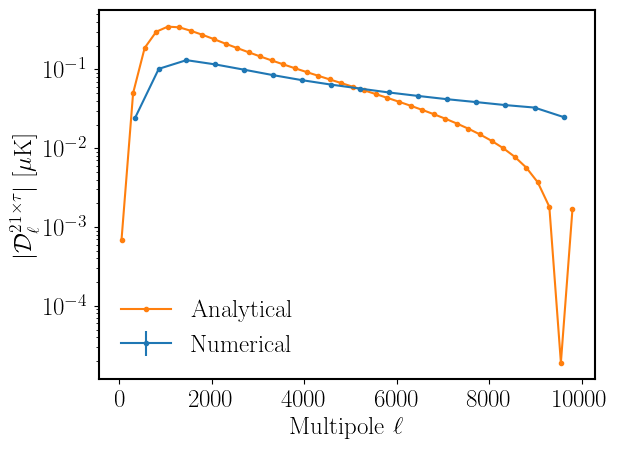

In [45]:
fig, ax = plt.subplots(1,1,)
m = Cl21_tau != 0.
ax.errorbar(
    l[m], l[m] * (l[m]+1.) * Cl21_tau[m] / 2. / np.pi,
    yerr=l[m] * (l[m]+1.) * Cl21_tau_err[m] / 2./np.pi,
     marker='.', label='Numerical')
iz = 4
ax.plot(ells, np.abs(model.get_tau_21_cross(zarr[iz], ells, Dells=True, delta_nu=0.)).to(units.uK), marker='.', label='Analytical')

# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\vert\mathcal{D}_\ell^{21\times \tau}\vert$ [$\mu$K]')
ax.legend(frameon=False)
ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


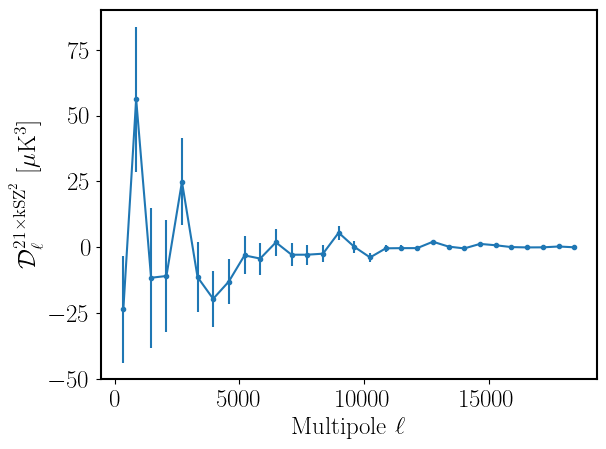

In [46]:
fig, ax = plt.subplots()
m = Cl21_ksz2 != 0.
ax.errorbar(
    l[m], l[m] * (l[m]+1.) * Cl21_ksz2 [m] / 2. / np.pi,
    yerr=l[m] * (l[m]+1.) * Cl21_ksz2_err [m] / 2./np.pi,
     marker='.')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \mathrm{kSZ}^2}$ [$\mu$K$^3$]')
ax.legend(frameon=False)
# ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     

20it [23:26, 70.34s/it]


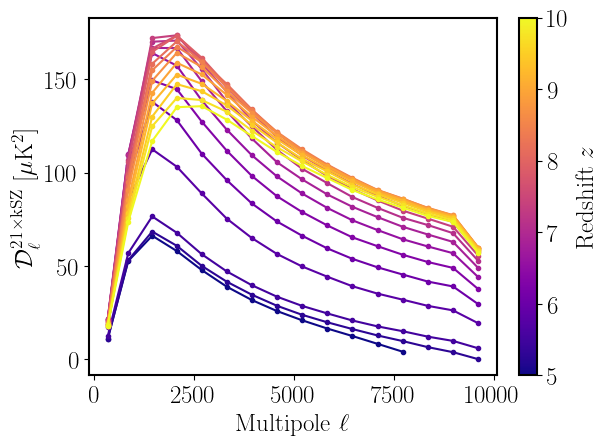

In [47]:
cmap = colormaps['plasma']
norm = colors.Normalize(vmin=np.min(zarr), vmax=np.max(zarr)) #can also use LogNorm


fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    l, Cl21_ksz_temp, Cl21_ksz_err_temp = compute_cross_angular_spectrum(ksz_box, dTb_maps[iz], fov.to(units.rad).value, nbins=30)
    m = Cl21_ksz_temp != 0.
    ax.errorbar(
        l[m], l[m] * (l[m]+1.) * Cl21_ksz_temp [m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * Cl21_ksz_err_temp [m] / 2./np.pi,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \mathrm{kSZ}}$ [$\mu$K$^2$]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
# ax.set_yscale('log')

0it [00:00, ?it/s]/Users/adeliegorce/Library/CloudStorage/OneDrive-McGillUniversity/Research/cross-correlations/With_Pee/utils.py:297: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(pk2-pk**2),
20it [23:13, 69.65s/it]


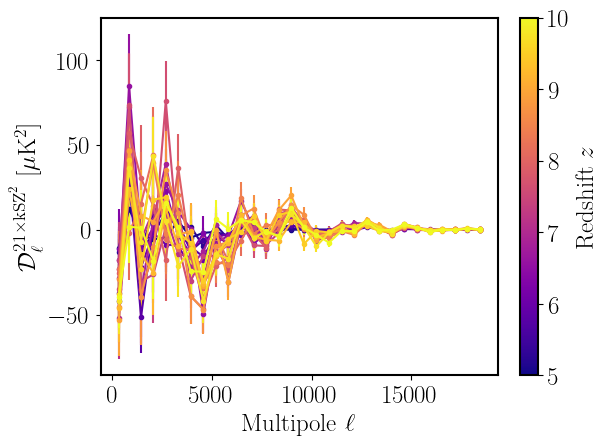

In [48]:
cmap = colormaps['plasma']
norm = colors.Normalize(vmin=np.min(zarr), vmax=np.max(zarr)) #can also use LogNorm

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    l, Cl21_ksz_temp, Cl21_ksz_err_temp = compute_cross_angular_spectrum(ksz_box**2, dTb_maps[iz], fov.to(units.rad).value, nbins=30)
    m = Cl21_ksz_temp != 0.
    ax.errorbar(
        l[m], l[m] * (l[m]+1.) * Cl21_ksz_temp [m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * Cl21_ksz_err_temp [m] / 2./np.pi,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \mathrm{kSZ}^2}$ [$\mu$K$^2$]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
# ax.set_yscale('log')

100%|██████████| 3/3 [06:08<00:00, 122.89s/it]
/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_9703/2710046512.py:28: RuntimeWarning: invalid value encountered in divide
  plt.plot(cl3/Clksz_ksz)


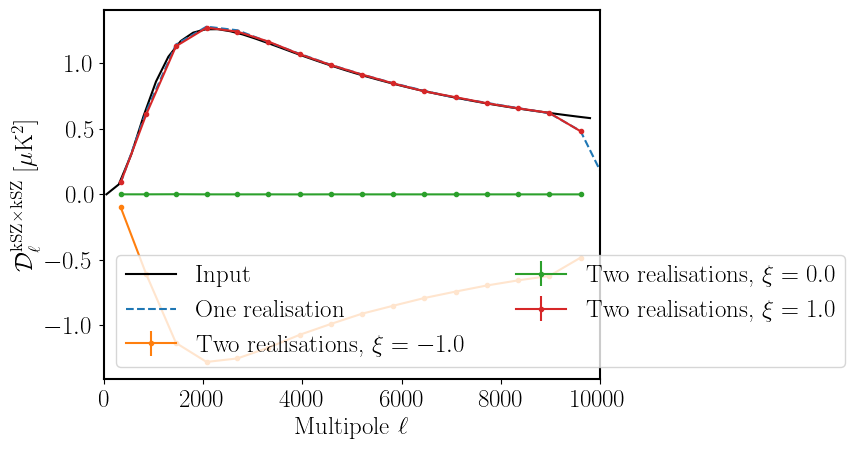

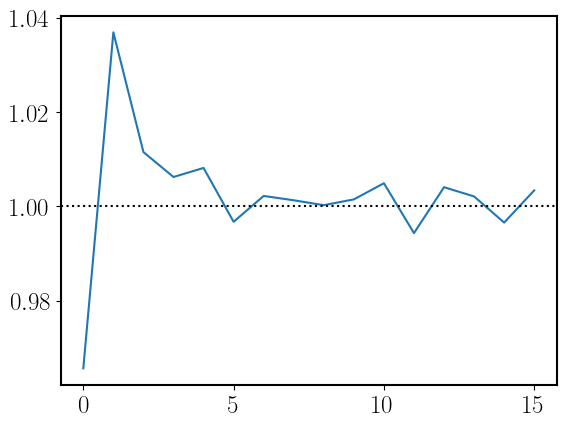

In [49]:
pk_array1 = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

box1 = simulations.gaussian_box_from_cl(
        N, fov.to(units.rad).value,
        pk_array1, ndim=3,
)
l3, cl3, el3 = compute_cl_from_box(box1, fov.to(units.rad).value)

fig, ax = plt.subplots()
ax.plot(pk_array1[0], pk_array1[1] * pk_array1[0] * (pk_array1[0] + 1.) / 2./ np.pi, color='k', label='Input')
ax.plot(l3, cl3 * l3 * (l3+1.) / 2. / np.pi, ls='--', label='One realisation')
for xi in tqdm([-1., 0., 1.]):
        l, Clksz_ksz, Clksz_ksz_err = get_cross_spectrum(
                pk_array1, pk_array1, xi=xi, is_21=0, 
                ndim=3, N=512, fov=fov, cos=cosmology.Planck18,
                nbins=30)
        m = Clksz_ksz != 0.
        ax.errorbar(
                l[m], l[m] * (l[m]+1.) * Clksz_ksz[m] / 2. / np.pi,
                yerr=l[m] * (l[m]+1.) * Clksz_ksz_err[m] / 2./np.pi,
                marker='.', label=rf'Two realisations, $\xi={xi}$')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{\mathrm{kSZ}\times \mathrm{kSZ}}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 1e4)
plt.legend(ncols=2)

plt.figure()
plt.plot(cl3/Clksz_ksz)
plt.axhline(1., color='k', ls=':')

100%|██████████| 3/3 [06:03<00:00, 121.20s/it]
/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_9703/2454056364.py:30: RuntimeWarning: invalid value encountered in divide
  plt.plot(cl3/Clksz_ksz)


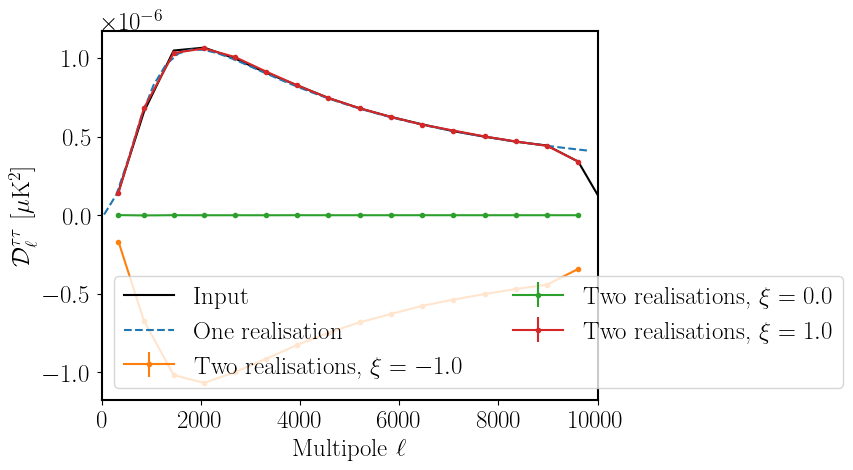

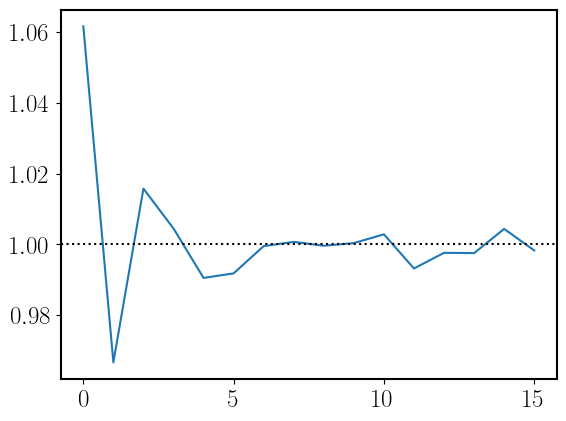

In [50]:
pk_array1 = np.c_[ells, tau_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T

box1 = simulations.gaussian_box_from_cl(
        N, fov.to(units.rad).value,
        pk_array1, ndim=3,
)

l3, cl3, el3 = compute_cl_from_box(box1, fov.to(units.rad).value)

fig, ax = plt.subplots()
ax.plot(l3, cl3 * l3 * (l3+1.) / 2. / np.pi, ls='-', color='k', label='Input')
ax.plot(pk_array1[0], pk_array1[1] * pk_array1[0] * (pk_array1[0]+1.) / 2. / np.pi,
        ls='--', label='One realisation')
for xi in tqdm([-1., 0., 1.]):
        l, Clksz_ksz, Clksz_ksz_err = get_cross_spectrum(
                pk_array1, pk_array1, xi=xi, is_21=0, 
                ndim=3, N=512, fov=fov, cos=cosmology.Planck18,
                nbins=30,)
        m = Clksz_ksz != 0.
        ax.errorbar(
                l[m], l[m] * (l[m]+1.) * Clksz_ksz[m] / 2. / np.pi,
                yerr=l[m] * (l[m]+1.) * Clksz_ksz_err[m] / 2./np.pi,
                marker='.', label=rf'Two realisations, $\xi={xi}$')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{\tau\tau}_\ell$ [$\mu$K$^2$]')
plt.xlim(0, 1e4)
plt.legend(ncols=2)

plt.figure()
plt.plot(cl3/Clksz_ksz)
plt.axhline(1., color='k', ls=':')

6.052631578947368 [0.84538684]


Text(0, 0.5, '$\\mathcal{D}^{21\\times \\mathrm{kSZ}}_\\ell$ [$\\mu$K$^2$]')

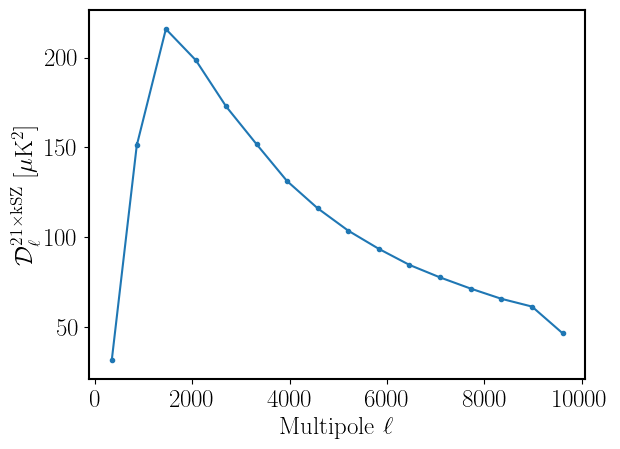

In [51]:
iz = 4
pk_array1 = np.c_[karr, ps_21[iz]*1e6].T  # muK2
pk_array2 = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T  # muK2
print(zarr[iz], model.xe(zarr[iz]))

l, Cl21_ksz, Cl21_ksz_err = get_cross_spectrum(
        pk_array1, pk_array2, xi=1., is_21=1, z21=zarr[iz],
        ndim=3, N=512, fov=fov, cos=cosmology.Planck18,
        nbins=30,)

fig, ax = plt.subplots()
m = Cl21_ksz != 0.
ax.errorbar(
        l[m], l[m] * (l[m]+1.) * Cl21_ksz[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * Cl21_ksz_err[m] / 2./np.pi,
        marker='.')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{21\times \mathrm{kSZ}}_\ell$ [$\mu$K$^2$]')
# ax.legend(frameon=False)
# ax.set_xscale('log')
# ax.set_yscale('symlog', linthresh=1e-8)     


6.052631578947368 [0.84538684]


100%|██████████| 10/10 [20:01<00:00, 120.13s/it]


Text(0, 0.5, '$\\mathcal{D}^{21\\times \\mathrm{kSZ}^2}_\\ell$ [$\\mu$K$^2$]')

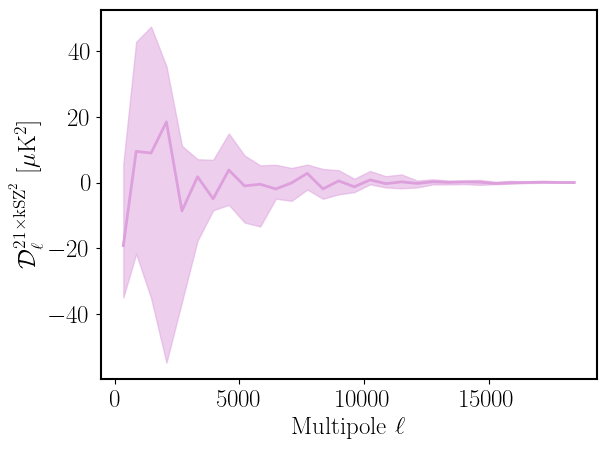

In [52]:
iz = 4
pk_array1 = np.c_[karr, ps_21[iz]*1e6].T  # muK2
L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
pk_array2 = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T  # muK2
print(zarr[iz], model.xe(zarr[iz]))

nit = 10
Cl21_ksz_list = []
for i in tqdm(range(nit)):
    phases_bis = np.random.random(size) * 2. * np.pi
    ksz_box_temp = gaussian_box_from_cl(
        N, fov.to(units.rad).value, 
        pk_array2, ndim=ndim, phases=phases_bis
    )
    box_21_temp = gaussian_box_from_ps(
        N, L21,
        pk_array1, ndim=ndim, phases=phases_bis
    )
    # Cl21_ksz_list.append(get_cross_spectrum(
    #         pk_array1, pk_array2, xi=1., is_21=1, z21=zarr[iz],
    #         ndim=3, N=512, fov=fov, cos=cosmology.Planck18,
    #         nbins=30,)[1])
    Cl21_ksz_list.append(compute_cross_angular_spectrum(
        ksz_box_temp**2, box_21_temp, 
        fov.to(units.rad).value, nbins=30
    )[1])
Cl21_ksz_list = np.array(Cl21_ksz_list)

Dl21_ksz_list = l * (l+1) * Cl21_ksz_list / 2. / np.pi

fig, ax = plt.subplots()
ax.fill_between(
    l,
    np.percentile(Dl21_ksz_list, percentile2, axis=0),
    np.percentile(Dl21_ksz_list, percentile1, axis=0),
    color='plum', alpha=0.5
)
ax.plot(
    l, np.median(Dl21_ksz_list, axis=0),
    color='plum', linestyle='-', linewidth=2,
)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{21\times \mathrm{kSZ}^2}_\ell$ [$\mu$K$^2$]')

0.1


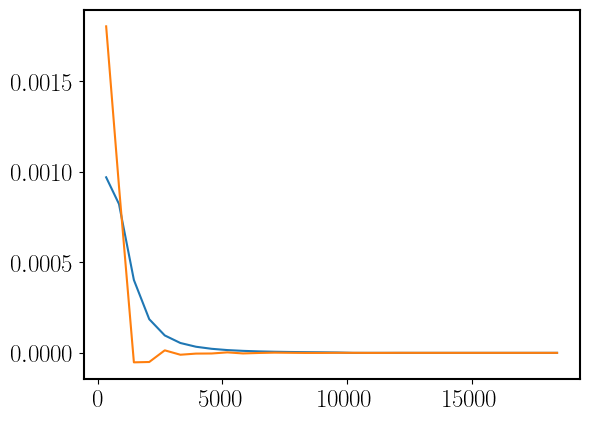

In [53]:
kappa = .1
iz = 4
phases_bis = np.random.random(size) * 2. * np.pi

print(kappa)
model = Pee_model(
    kappa=kappa,
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=False, run_camb=True)

L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
pk_array1 = np.c_[karr, model.get_p21(karr, zarr[iz], mK=True, log=False, pk_units=True).flatten()*1e6].T  # muK2
box_21_temp = gaussian_box_from_ps(
    N, L21,
    pk_array1, ndim=ndim, phases=phases_bis
)

ksz_ps = model.get_ksz(ells=ells, signal='both', Dells=True)
pk_array2 = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T  # muK2
ksz_box_temp = gaussian_box_from_cl(
    N, fov.to(units.rad).value, 
    pk_array2, ndim=ndim, phases=phases_bis
)

plt.plot(l, compute_cross_angular_spectrum(ksz_box_temp, box_21_temp, fov.to(units.rad).value, nbins=30)[1])
plt.plot(l, compute_cross_angular_spectrum(ksz_box_temp**2, box_21_temp, fov.to(units.rad).value, nbins=30)[1])

In [54]:
kappa_arr = np.logspace(-2, -.5, 5)
iz = 4
phases_bis = np.random.random(size) * 2. * np.pi

Cl21_ksz_list_v_kappa = []
Cl21_ksz2_list_v_kappa = []
for ik, kappa in enumerate(kappa_arr):
    print(kappa)
    model = Pee_model(
        kappa=kappa,
        h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
        verbose=False, run_camb=True)

    L21 = np.tan(fov.to(units.rad).value/2.) * 2. * cos.comoving_distance(zarr[iz]).value
    pk_array1 = np.c_[karr, model.get_p21(karr, zarr[iz], mK=True, log=False, pk_units=True).flatten()*1e6].T  # muK2
    box_21_temp = gaussian_box_from_ps(
        N, L21,
        pk_array1, ndim=ndim, phases=phases_bis
    )

    ksz_ps = model.get_ksz(ells=ells, signal='both', Dells=True)
    pk_array2 = np.c_[ells, ksz_ps[:, 0]/ells/(ells + 1)*2.0*np.pi].T  # muK2
    ksz_box_temp = gaussian_box_from_cl(
        N, fov.to(units.rad).value, 
        pk_array2, ndim=ndim, phases=phases_bis
    )

    Cl21_ksz_list_v_kappa.append(compute_cross_angular_spectrum(
        ksz_box_temp, box_21_temp, 
        fov.to(units.rad).value, nbins=30
    )[1])
    Cl21_ksz2_list_v_kappa.append(compute_cross_angular_spectrum(
        ksz_box_temp**2, box_21_temp, 
        fov.to(units.rad).value, nbins=30
    )[1])

Cl21_ksz_list_v_kappa = np.array(Cl21_ksz_list_v_kappa)
Cl21_ksz2_list_v_kappa = np.array(Cl21_ksz2_list_v_kappa)


0.01


KeyboardInterrupt: 

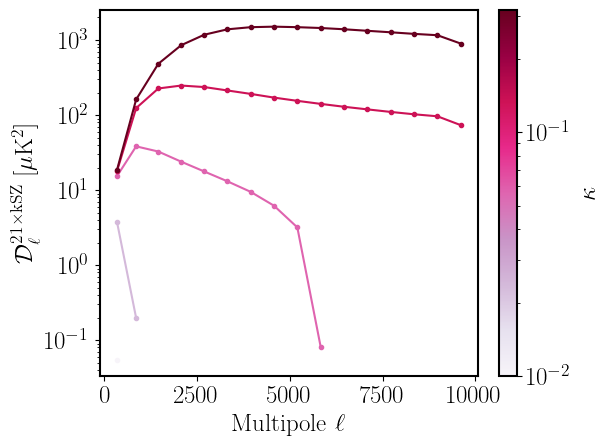

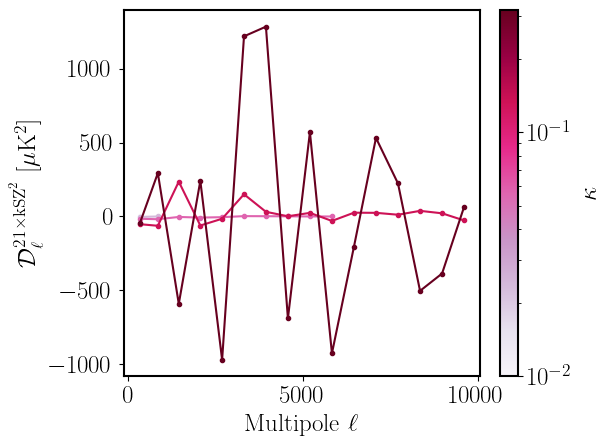

In [ ]:
cmap = colormaps['PuRd']
norm = colors.LogNorm(vmin=np.min(kappa_arr), vmax=np.max(kappa_arr)) #can also use LogNorm

fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()
for ik, kappa in enumerate(kappa_arr):
    m = Cl21_ksz_list_v_kappa[ik] != 0.
    ax.errorbar(
        l[m], l[m] * (l[m]+1.) * Cl21_ksz_list_v_kappa[ik][m] / 2. / np.pi,
        # yerr=l[m] * (l[m]+1.) * Cl21_ksz_err_temp [m] / 2./np.pi,
        marker='.', color=cmap(norm(kappa)))
    ax2.errorbar(
        l[m], l[m] * (l[m]+1.) * Cl21_ksz2_list_v_kappa[ik][m] / 2. / np.pi,
        # yerr=l[m] * (l[m]+1.) * Cl21_ksz_err_temp [m] / 2./np.pi,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(kappa)))
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\mathcal{D}_\ell^{21\times \mathrm{kSZ}}$ [$\mu$K$^2$]')
ax.set_yscale('log')
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylabel(r'$\mathcal{D}_\ell^{21\times \mathrm{kSZ}^2}$ [$\mu$K$^2$]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'$\kappa$')
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax2, label=r'$\kappa$')
fig.tight_layout()
fig2.tight_layout()


## With `healpy`

In [ ]:
import healpy as hp

In [ ]:
hp_ls = np.arange(int(ells.max()))

### kSZ map

In [109]:
interp_ksz = interp1d(ells, ksz_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
ksz_map = hp.synfast(interp_ksz(hp_ls), nside=2048, )# uK
ksz_map /= 1e3 #mK
ksz_ps2 = hp.anafast(ksz_map)

In [110]:
lrange = np.arange(ksz_ps2.size)

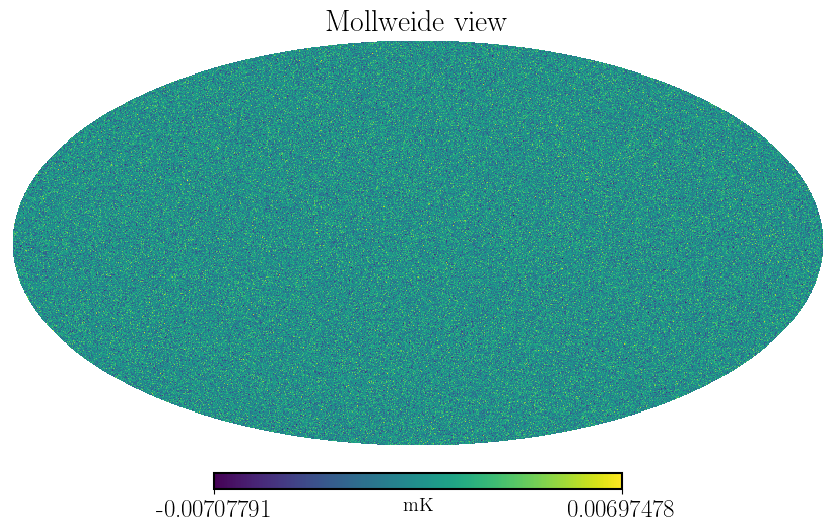

In [111]:
hp.mollview(ksz_map, unit='mK')

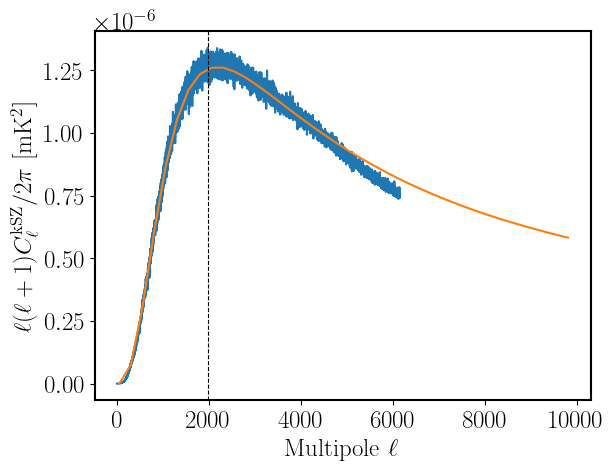

In [112]:
slope, intercept = 6.292754846642347e-05, -0.024391080262949116

plt.figure()
plt.plot(lrange, ksz_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, ksz_ps[:, 0]/1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}}/2\pi$ [mK$^2$]')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


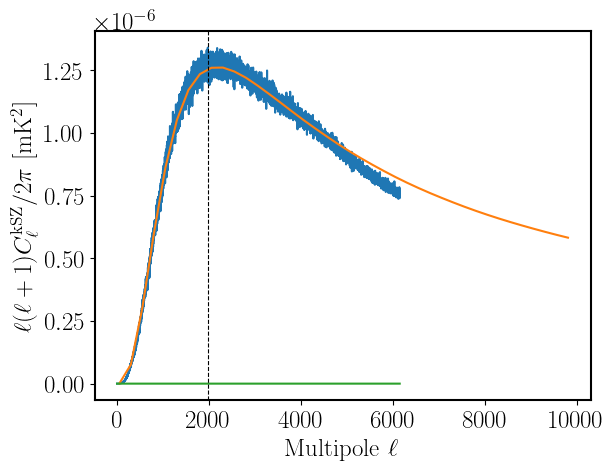

In [113]:
ksz2_ps = hp.anafast(ksz_map**2)
plt.figure()
plt.plot(lrange, ksz_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, ksz_ps[:, 0]/1e6)
plt.plot(lrange, ksz2_ps*lrange*(lrange+1)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}}/2\pi$ [mK$^2$]')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


### $\tau$ map

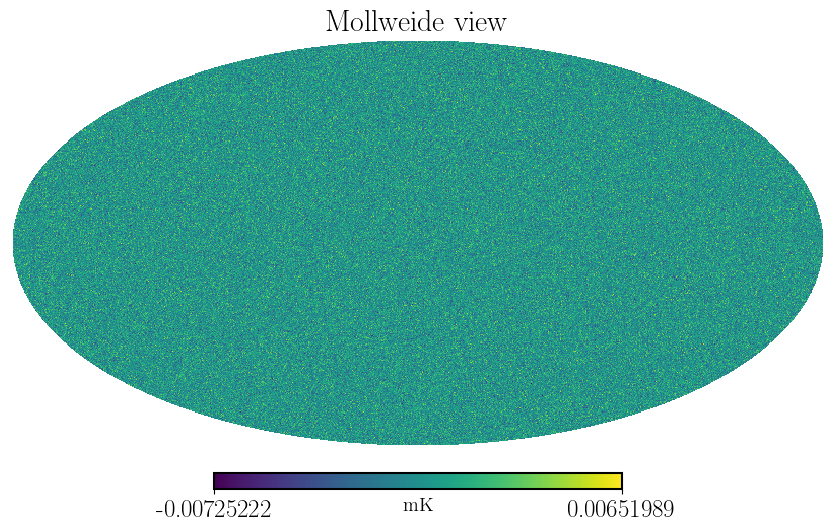

In [114]:
interp_tau = interp1d(ells, tau_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
tau_map = hp.synfast(interp_tau(hp_ls), nside=2048, ) #mK

hp.mollview(tau_map, unit='mK')


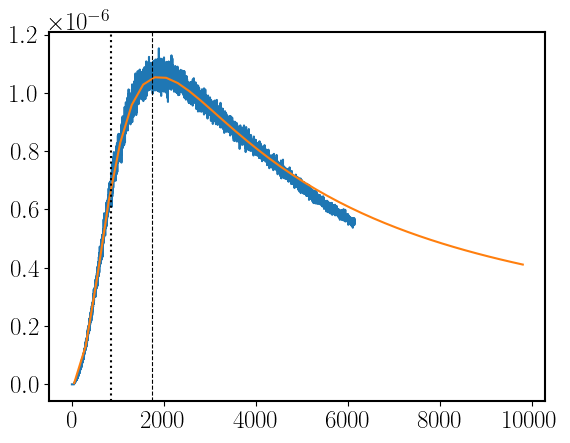

In [115]:
tau_ps2 = hp.anafast(tau_map)
slope, intercept = 6.292754846642347e-05, -0.01
plt.figure()
plt.plot(lrange, tau_ps2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, tau_ps[:, 0])
plt.axvline(model.kappa*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
plt.axvline((model.kappa-intercept)/slope, color='k', ls='--', lw=.8)


### 21cm power spectrum

In [273]:
from scipy.special import spherical_jn as jn

In [264]:
iz = 5
print(zarr[iz], model.xe(zarr[iz]))

6.315789473684211 [0.74912034]


$P_{2D}(k_\perp) = \int \mathrm{d}k\, P_{3D}(k_\perp, k_\parallel)$

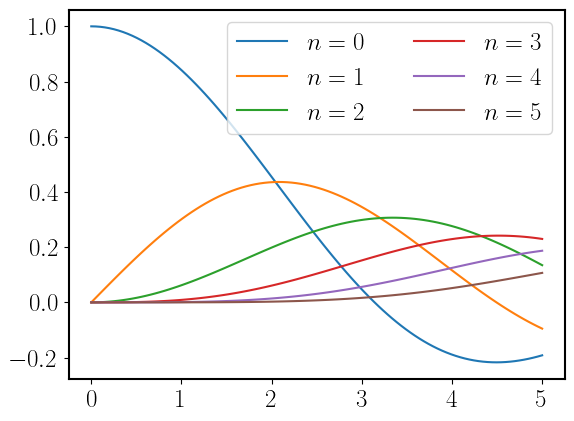

In [276]:
xlin = np.linspace(0, 5, 100)
for n in np.arange(0,6):
    plt.plot(xlin, jn(n, xlin), label=fr'$n={n}$')
plt.legend(ncols=2)

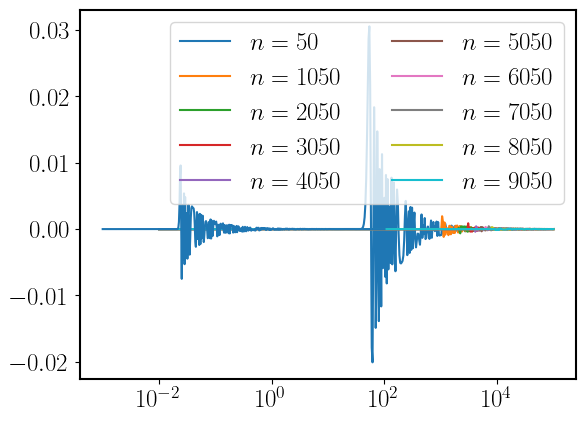

In [275]:
xlin = np.logspace(-2, 5, 500)
for n in ells[::4]:
    plt.semilogx(xlin, jn(int(n), xlin), label=fr'$n={n}$')
plt.legend(ncols=2)
plt.semilogx(klog, jn(200, klog*cos.comoving_distance(zarr[iz]).value)) 

In [274]:
Jarr = jn(np.array(ells, dtype=int)[:, None], karr*cos.comoving_distance(zarr[iz]).value)**2
print(Jarr.shape)

(40, 100)


In [121]:
xlin = np.linspace(0.1, 10., 100)
print(np.trapz(xlin**2, xlin))
xlog = np.logspace(-1, 1, 100)
print(np.trapz(xlog**2, xlog))

333.34950000000003
333.4531470637125


$C_\ell = \frac{2}{\pi} \int k^2 \mathrm{d}k\, P(k) j_\ell[k d_c(z)]$

5.432597655714892e-07 4.9419589223943e-07


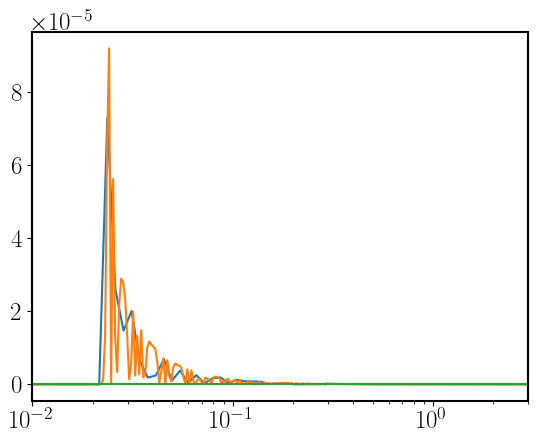

In [122]:
plt.figure()
# plt.plot(karr, karr**2 * ps_21[iz])
ell = 200
plt.semilogx(karr, jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2)
plt.semilogx(klog, jn(int(ell), klog*cos.comoving_distance(zarr[iz]).value)**2)    
plt.semilogx(klog, jn(int(ell), klog)**2)    
plt.xlim(1e-2, 3)
print(np.trapz(jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2, karr), np.trapz(jn(int(ell), klog*cos.comoving_distance(zarr[iz]).value)**2, klog))

(0.0, 3000.0)

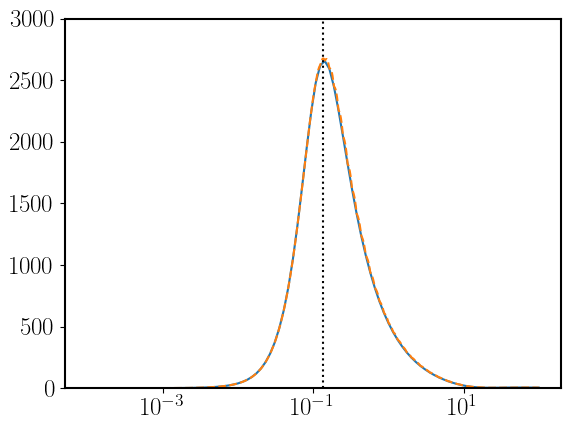

In [271]:
ps_21_interp = interp1d(karr, ps_21[iz], fill_value='extrapolate', bounds_error=False)

plt.figure()
ell = 200
plt.semilogx(karr, karr**2 * ps_21[iz])
plt.semilogx(klog, klog**2 * ps_21_interp(klog), ls='--')
# plt.axvline(model.kappa)
plt.axvline(model.kappa/model.xe(zarr[iz]), color='k', ls=':')
# plt.axhline(10**(model.alpha0)/2.)
plt.ylim(0, 3000)

(0.01, 1.0)

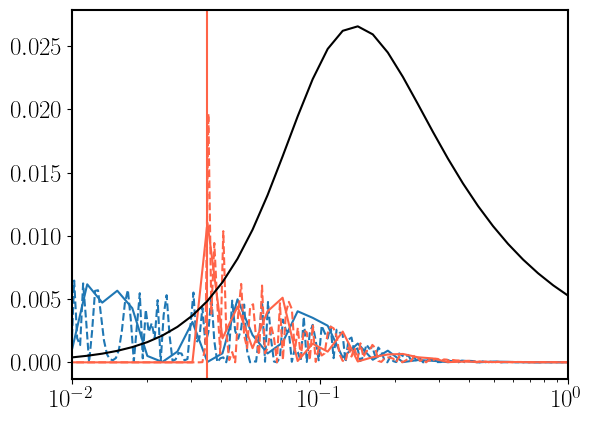

In [277]:
ell = 200
klog2 = np.logspace(np.log10(karr.min()), np.log10(karr.max()), 500)
plt.figure()
for u, (ell, color) in enumerate(zip(ells[:2], ['C0', 'tomato'])):
    plt.semilogx(karr, karr**2 * ps_21[iz] * jn(int(ell), karr*cos.comoving_distance(zarr[iz]).value)**2, color=color, ls='-')
    plt.semilogx(klog2, klog2**2 * ps_21_interp(klog2) * jn(int(ell), klog2*cos.comoving_distance(zarr[iz]).value)**2, color=color, ls='--')
    keta = (ell+0.5)/cos.comoving_distance(zarr[iz]).value
    # plt.axhline(keta**2 * ps_21_interp(keta) * np.pi/(2*ell+1.), color=color, ls='--')
    plt.axvline(keta, color=color)
plt.semilogx(karr, karr**2 * ps_21[iz] *1e-5, color="k", ls='-')
plt.xlim(1e-2, 1e0)


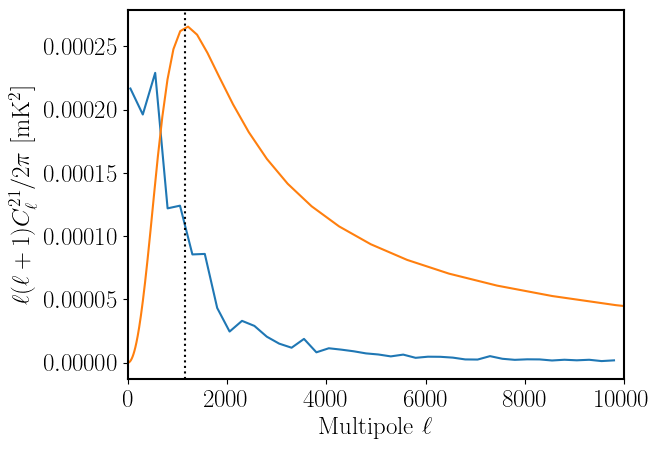

In [278]:
# iz = 4
# print(zarr[iz], model.xe(zarr[iz]))
cls_21 = ps_21[iz] * karr**2 
# cls_21 = 2./np.pi * np.trapz(karr**2 * ps_21[iz] * jn(np.array(ells, dtype=int)[:, None], karr*cos.comoving_distance(zarr[iz]).value), karr, axis=1)
cls_212 = 2./np.pi * np.trapz(klog2**2 * ps_21_interp(klog2) * jn(np.array(ells, dtype=int)[:, None], klog2*cos.comoving_distance(zarr[iz]).value)**2, klog2, axis=1)

ells_21 = karr * cos.comoving_distance(zarr[iz]).value

plt.figure()
# plt.semilogy(ells_21, cls_21)#*(ells_21+1)*ells_21/2./np.pi)
plt.plot(ells, cls_212)#*(ells_21+1)*ells_21/2./np.pi)
plt.plot(ells_21, cls_21 / 1e7)
# plt.semilogy(ells_21, cls_21)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{21}/2\pi$ [mK$^2$]')
plt.xlim(0, 10000)
plt.axvline(model.kappa/model.xe(zarr[iz])*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
# plt.plot(hp_ls, interp_p21(hp_ls))


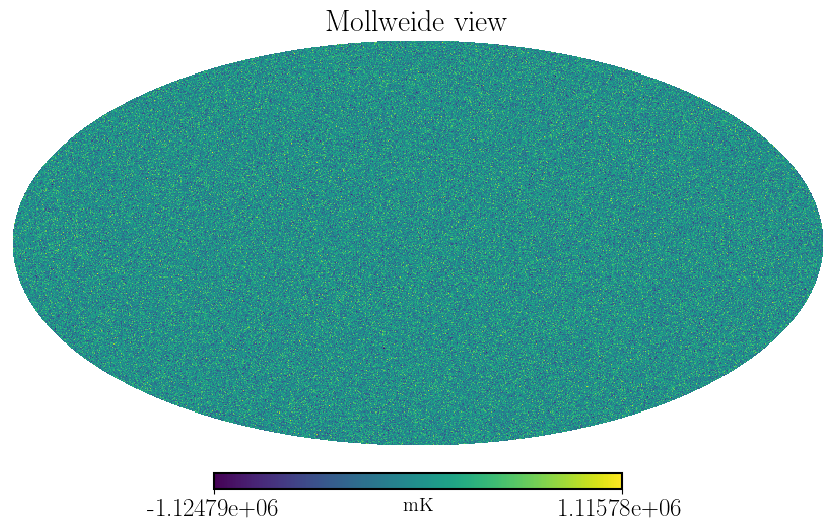

In [279]:
cls_21 = ps_21[iz] #* karr**2 
interp_p21 = interp1d(ells_21, cls_21, fill_value=0, bounds_error=False)
dTb_map = hp.synfast(interp_p21(hp_ls), nside=2048, )
p21_cls2 = hp.anafast(dTb_map)

hp.mollview(dTb_map, unit='mK')


Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell^{21}/2\\pi$ [mK$^2$]')

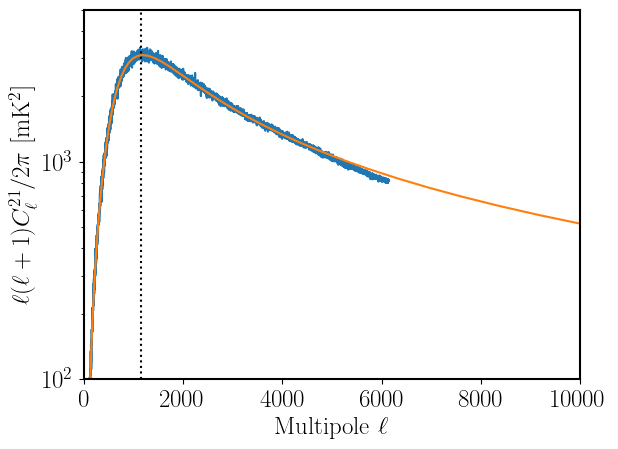

In [127]:
plt.figure()
plt.semilogy(lrange, p21_cls2*lrange*(lrange+1)/2./np.pi)
plt.plot(ells_21, cls_21*(ells_21+1)*ells_21/2./np.pi/1e7)
plt.axvline(model.kappa/model.xe(zarr[iz])*cos.comoving_distance(zarr[iz]).value, color='k', ls=':')
# plt.ylim(1e0, 1e3)
plt.ylim(1e2, 5e3)
plt.xlim(0, 10000)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{21}/2\pi$ [mK$^2$]')

### Cross-spectra

Text(0.5, 0, '$\\log a_{\\ell m}^{\\tau\\tau}$')

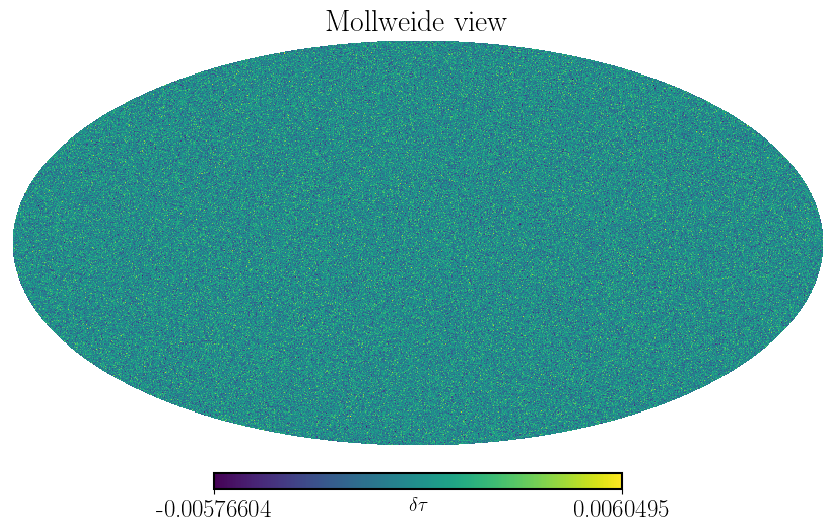

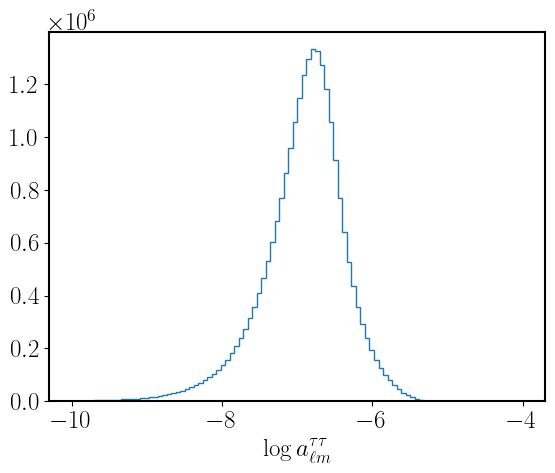

In [157]:
interp_tau = interp1d(ells, tau_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
tau_alm = hp.synalm(interp_tau(hp_ls), lmax=ells.max())
tau_alm[np.isnan(tau_alm)] = 0.
tau_alm[tau_alm<1e-24] = 0.
map_tau = hp.synfast(interp_tau(hp_ls), nside=1024)
hp.mollview(map_tau, unit=r'$\delta\tau$')
plt.figure()
_ = plt.hist(np.log10(tau_alm[tau_alm!=0].real), bins=100, range=(-10, -4), histtype='step')
plt.xlabel(r'$\log a_{\ell m}^{\tau\tau}$')

/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_14301/2494454246.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(hp_ls, interp_21_tau(hp_ls)/interp_tau(hp_ls))


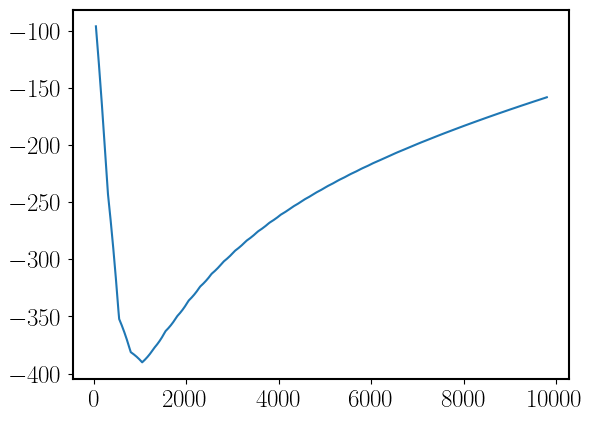

In [ ]:
plt.figure()
plt.plot(hp_ls, interp_21_tau(hp_ls)/interp_tau(hp_ls))

/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_14301/803974303.py:3: RuntimeWarning: invalid value encountered in divide
  alm_cross = hp.almxfl(tau_alm, -interp_21_tau(hp_ls)/interp_tau(hp_ls))


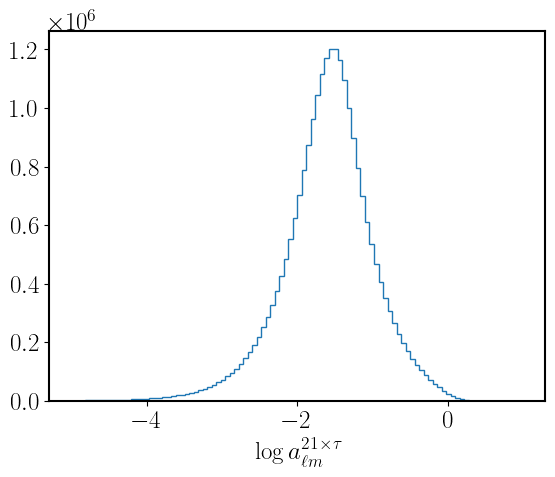

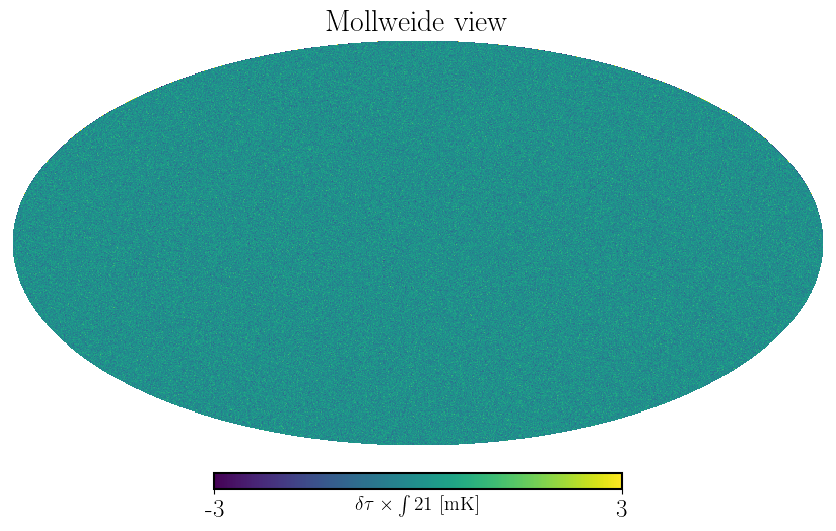

In [ ]:
cl_21_tau = model.get_tau_21_cross(np.mean(zarr), ells, Dells=False, delta_nu=bandwidth).to(units.mK).value
interp_21_tau = interp1d(ells, cl_21_tau, fill_value=0, bounds_error=False)
alm_cross = hp.almxfl(tau_alm, -interp_21_tau(hp_ls)/interp_tau(hp_ls))
alm_cross[np.isnan(alm_cross)] = 0.
alm_cross[alm_cross<1e-24] = 0.
plt.figure()
_ = plt.hist(np.log10(alm_cross[alm_cross!=0].real), bins=100, range=(-8, -2), histtype='step')
plt.xlabel(r'$\log a_{\ell m}^{21\times\tau}$')
tau_int21_map = hp.alm2map(alm_cross, nside=1024, ) #uK
hp.mollview(tau_int21_map, unit=r'$\delta\tau \times \int 21$ [mK]', min=-3, max=3)

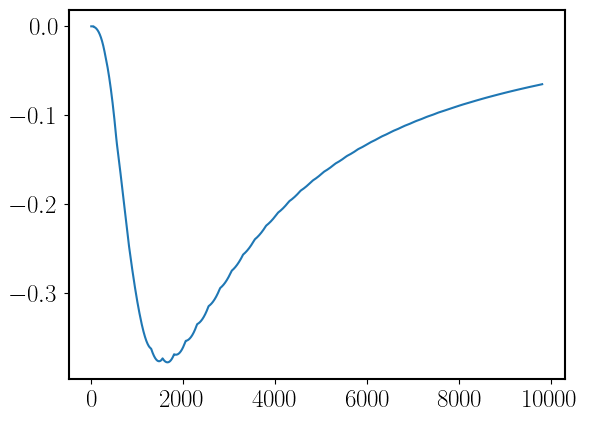

In [262]:
plt.plot(hp_ls, interp_21_tau(hp_ls)*hp_ls*(hp_ls+1)/2./np.pi)

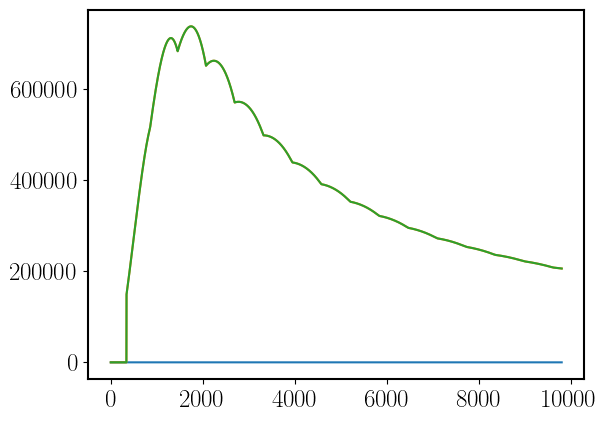

In [260]:
interp_cl_21_21 = interp1d(l, Cl_int21_int21, fill_value=0, bounds_error=False)  # mK2
plt.plot(hp_ls, interp_21_tau(hp_ls)*hp_ls*(hp_ls+1)/2./np.pi)
plt.plot(hp_ls, interp_cl_21_21(hp_ls)*hp_ls*(hp_ls+1)/2./np.pi)
plt.plot(hp_ls, (interp_cl_21_21(hp_ls)-interp_21_tau(hp_ls))*hp_ls*(hp_ls+1)/2./np.pi)

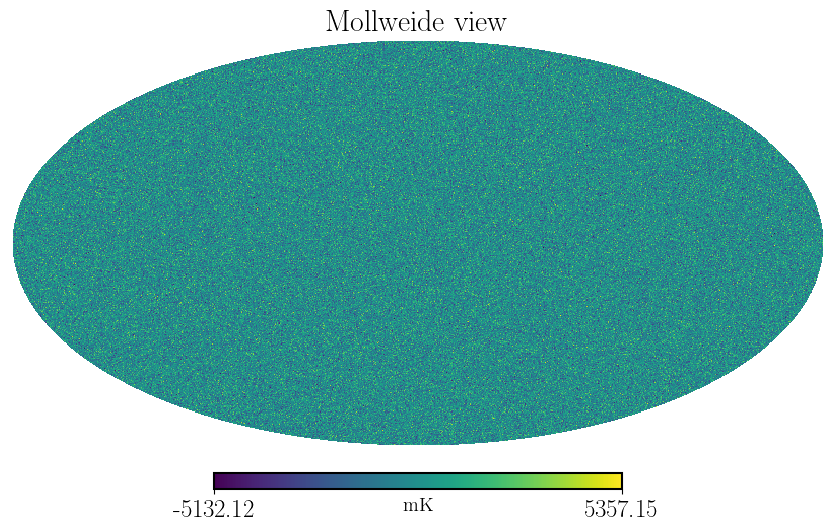

In [259]:
alm_21 = hp.synalm(interp_cl_21_21(hp_ls))#-interp_21_tau(hp_ls), lmax=ells.max()) + alm_cross
map_21 = hp.alm2map(alm_21, nside=1024)
hp.mollview(map_21, unit='mK')

In [210]:
cl_21_tau = hp.anafast(map1=map_tau, map2=map_21)
lrange = np.arange(cl_21_tau.size)

In [211]:
model.get_tau_21_cross(np.mean(zarr), ells, Dells=True, delta_nu=bandwidth).to(units.uK)


<Quantity [-0.00041667, -0.03151928, -0.12936683, -0.23928829, -0.32336354,
           -0.36236945, -0.37351708, -0.3688666 , -0.35380053, -0.33503166,
           -0.31473681, -0.29443488, -0.27498522, -0.25672394, -0.23979114,
           -0.22420298, -0.2098983 , -0.19679923, -0.18481155, -0.17383079,
           -0.16375667, -0.15449841, -0.14597448, -0.13811167, -0.13084435,
           -0.12411376, -0.11786743, -0.11205863, -0.10664584, -0.10159218,
           -0.09686486, -0.09243472, -0.08827575, -0.08436474, -0.08068093,
           -0.07720572, -0.07392238, -0.07081585, -0.06787254, -0.06508014] uK>

(-0.06072444529363798, 0.06047787187969373)

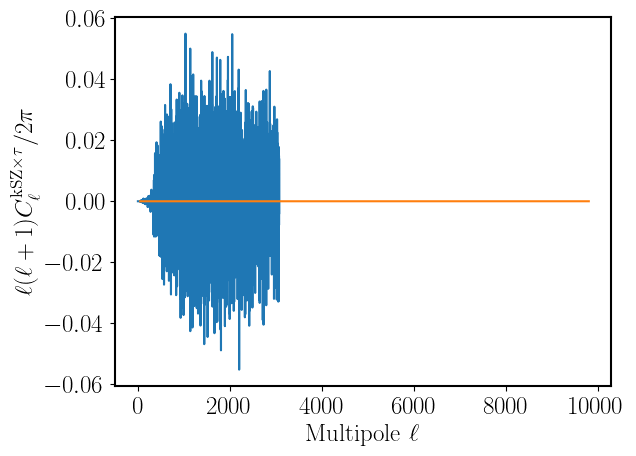

In [212]:
plt.figure()
plt.plot(lrange, cl_21_tau*lrange*(lrange+1)/2./np.pi)# * (model.T_cmb * 1e6) ** 2)
plt.plot(ells, model.get_tau_21_cross(np.mean(zarr), ells, Dells=False, delta_nu=bandwidth).to(units.uK).value)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\times\int \delta T_b}/2\pi$')
plt.ylim()

In [128]:
dell = np.diff(ells).mean()
ells_edges = np.arange(ells.min()-dell/2., ells.max()+dell, step=dell)
print(ells_edges.min(), dell, ells.min())
print(ells_edges.max(), dell, ells.max())

-75.0 250.0 50
9925.0 250.0 9800


In [129]:
lrange = np.arange(ksz_ps2.size)
binned_cl_ksz = bin_spectrum(lrange, ksz_ps2, ells_edges)
binned_cl_ps21 = bin_spectrum(lrange, p21_cls2, ells_edges)
binned_cl_tau = bin_spectrum(lrange, tau_ps2, ells_edges)


[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [ 2.11661161e-14 -2.62715264e-15  4.58492787e-15  9.70893746e-15
 -4.96627887e-15 -2.59713489e-15 -4.59605805e-15  9.24219384e-16
  9.34918932e-16 -2.52196855e-15 -7.14034890e-16 -2.77988691e-16
 -1.11647167e-15 -6.05208038e-16 -1.04630294e-16  2.19297048e-16
  8.52517635e-17 -1.14737059e-16  1.81385276e-16 -9.39955468e-17
  6.07322195e-17 -9.66541712e-17 -8.22211173e-17 -4.21658012e-17
 -9.63197848e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell^{\\mathrm{kSZ}\\times\\tau}/2\\pi$')

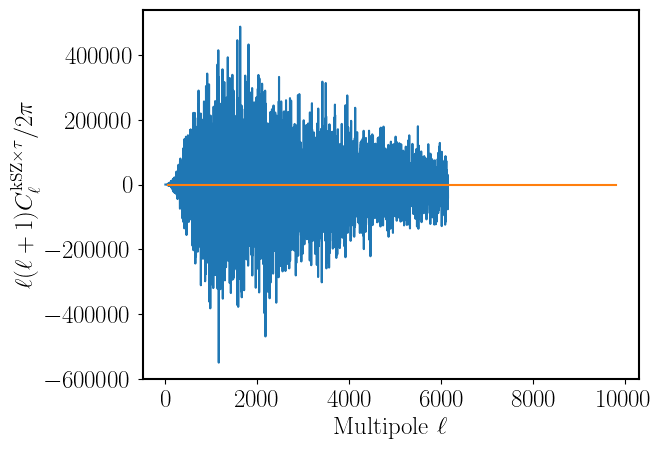

In [130]:
cl_ksz_tau = hp.anafast(map1=ksz_map, map2=tau_map)
binned_cl_ksz_tau = bin_spectrum(lrange, cl_ksz_tau, ells_edges)
print(ells, binned_cl_ksz_tau)

plt.figure()
plt.plot(lrange, cl_ksz_tau*lrange*(lrange+1)/2./np.pi * (model.T_cmb * 1e6) ** 2)
plt.plot(ells, binned_cl_ksz_tau*ells*(ells+1.)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}\times\tau}/2\pi$')
# plt.ylim(-2e-3, 2e-3)
# plt.legend(frameon=False)

/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_34847/3999412657.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, binned_cl_ksz_tau/np.sqrt(binned_cl_ksz*binned_cl_tau))


Text(0, 0.5, '$r_\\ell=C_\\ell^{\\mathrm{kSZ}\\times\\tau}/\\sqrt{C_\\ell^{\\mathrm{kSZ}}C_\\ell^{\\tau}}$')

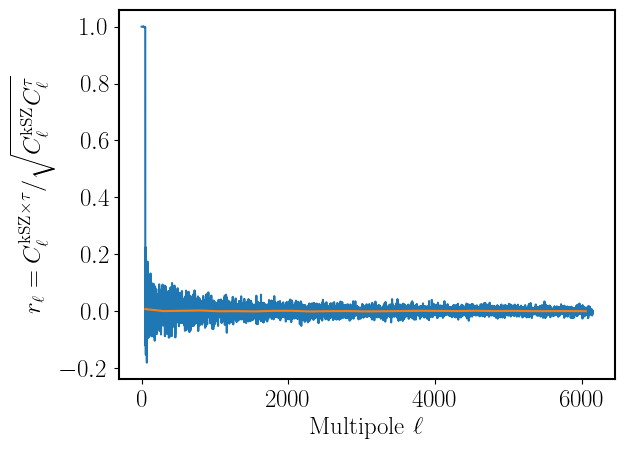

In [131]:
plt.figure()
plt.plot(lrange, cl_ksz_tau/np.sqrt(ksz_ps2*tau_ps2))
plt.plot(ells, binned_cl_ksz_tau/np.sqrt(binned_cl_ksz*binned_cl_tau))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$r_\ell=C_\ell^{\mathrm{kSZ}\times\tau}/\sqrt{C_\ell^{\mathrm{kSZ}}C_\ell^{\tau}}$')
# plt.ylim(-2e-3, 2e-3)
# plt.legend(frameon=False)
# plt.xscale('log')
# plt.xlim(0, 10000)

In [132]:
# test = np.arange(-10,500,step=10)
# binned_cl_ksz_21, _ = np.histogram(cl_ksz_21*np.arange(cl_ksz_21.size)*(np.arange(cl_ksz_21.size)+1)/2./np.pi, bins=test, weights=cl_ksz_21*np.arange(cl_ksz_21.size)*(np.arange(cl_ksz_21.size)+1)/2./np.pi)
# print(test, binned_cl_ksz_21)
# plt.figure()
# # plt.plot(np.arange(cl_ksz_21.size), cl_ksz_21*np.arange(cl_ksz_21.size)*(np.arange(cl_ksz_21.size)+1)/2./np.pi)
# plt.plot((test[1:]+test[:-1]/2.), binned_cl_ksz_21)
# plt.xlabel(r'Multipole $\ell$')
# plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}\tau}/2\pi$')
# plt.ylim(-0.005, 0.005)

[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [ 2.24773252e-10 -5.99929137e-10  3.02641526e-10 -2.57966175e-10
  8.41231148e-10  1.22316635e-10  8.66175082e-11 -3.46248942e-10
  3.58300894e-12  1.08245185e-10  3.79434460e-12 -7.80036208e-12
 -4.63421672e-11 -1.87528914e-12 -1.26283521e-12  5.32070459e-12
 -3.83345109e-12 -7.48613072e-12 -8.35380635e-13 -6.56410085e-12
 -6.19653893e-12 -6.45491081e-13 -7.39501469e-12 -3.41211934e-12
 -1.41729159e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_34847/2631756116.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, binned_cl_ksz_21/np.sqrt(binned_cl_ksz*binned_cl_ps21))


Text(0, 0.5, '$r_\\ell=C_\\ell^{\\mathrm{kSZ}\\times21}/\\sqrt{C_\\ell^{\\mathrm{kSZ}}C_\\ell^{21}}$')

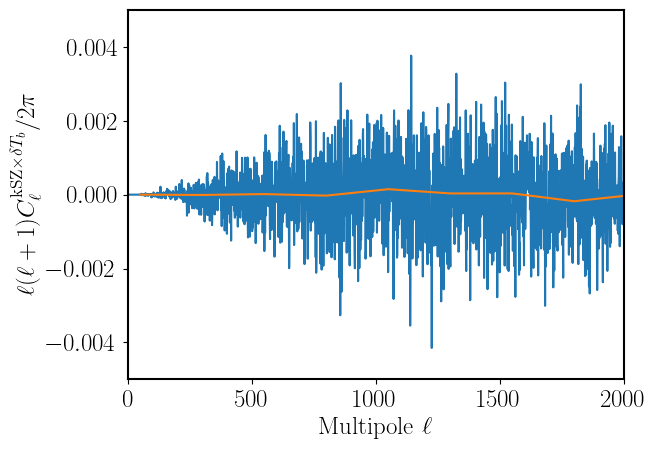

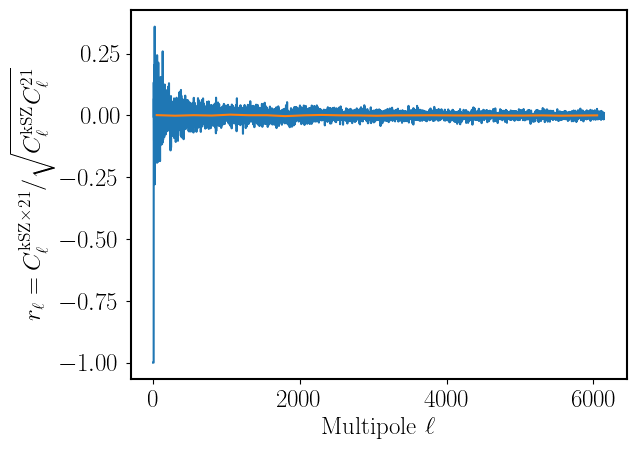

In [133]:
cl_ksz_21 = hp.anafast(map1=ksz_map, map2=dTb_map)
lrange = np.arange(cl_ksz_21.size)
binned_cl_ksz_21 = bin_spectrum(lrange, cl_ksz_21, ells_edges)

print(ells, binned_cl_ksz_21)

plt.figure()
plt.plot(lrange, cl_ksz_21*lrange*(lrange+1.)/2./np.pi)
plt.plot(ells, binned_cl_ksz_21*ells*(ells+1.)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}\times \delta T_b}/2\pi$')
plt.ylim(-0.005, 0.005)
plt.xlim(0, 2000)

plt.figure()
plt.plot(lrange, cl_ksz_21/np.sqrt(ksz_ps2*p21_cls2))
plt.plot(ells, binned_cl_ksz_21/np.sqrt(binned_cl_ksz*binned_cl_ps21))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$r_\ell=C_\ell^{\mathrm{kSZ}\times21}/\sqrt{C_\ell^{\mathrm{kSZ}}C_\ell^{21}}$')


[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [-3.27666981e-08  8.73778206e-08  8.56028798e-08  5.78936346e-08
  3.50717309e-08  7.99498768e-09  2.76108148e-09 -1.93210567e-09
 -1.25004989e-08  1.59315394e-08  6.01840084e-09  3.10769900e-09
  9.97948015e-10  1.12970218e-09 -1.47075607e-09  6.42428678e-10
 -1.70336440e-09  6.15671068e-10 -4.99295813e-10 -3.13431083e-10
  6.61599623e-10  9.77866414e-10  3.98935781e-10 -3.74803872e-10
 -3.25050785e-10  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_34847/1584567487.py:16: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, binned_cl_ksz_212/np.sqrt(binned_cl_ksz*binned_cl_ps212))


Text(0, 0.5, '$r_\\ell=C_\\ell^{\\mathrm{kSZ}\\times \\delta T_b^2}/\\sqrt{C_\\ell^{\\mathrm{kSZ}}C_\\ell^{\\delta T_b^2}}$')

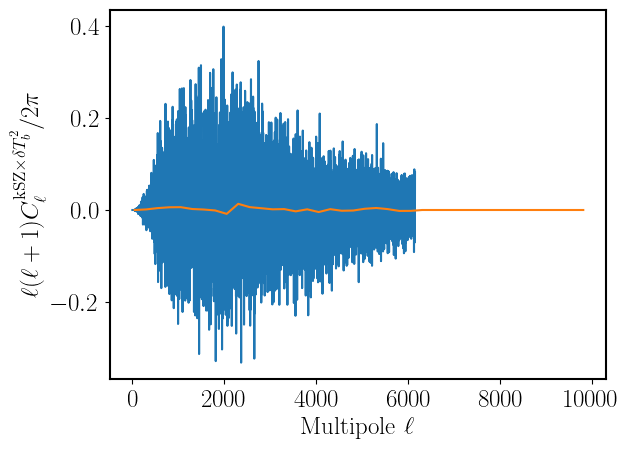

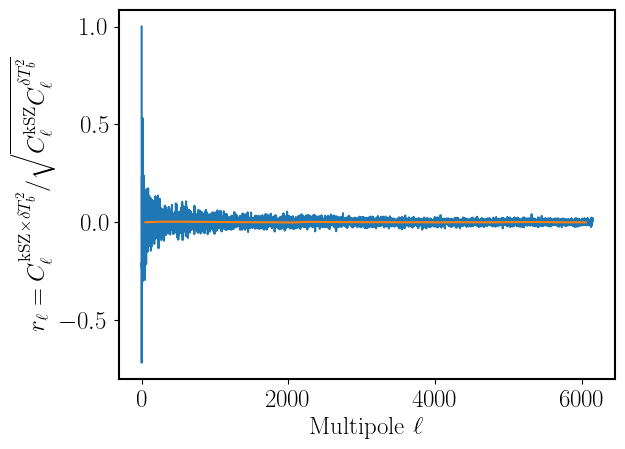

In [134]:
cl_ksz_212 = hp.anafast(ksz_map,  dTb_map**2)
binned_cl_ksz_212 = bin_spectrum(lrange, cl_ksz_212, ells_edges,)
print(ells, binned_cl_ksz_212)

plt.figure()
plt.plot(lrange, cl_ksz_212*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, binned_cl_ksz_212*ells*(ells+1)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}\times \delta T_b^2}/2\pi$')

p212_cls2 = hp.anafast(map1=dTb_map**2)
binned_cl_ps212 = bin_spectrum(lrange, p212_cls2, ells_edges,)

plt.figure()
plt.plot(lrange, cl_ksz_212/np.sqrt(ksz_ps2*p212_cls2))
plt.plot(ells, binned_cl_ksz_212/np.sqrt(binned_cl_ksz*binned_cl_ps212))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$r_\ell=C_\ell^{\mathrm{kSZ}\times \delta T_b^2}/\sqrt{C_\ell^{\mathrm{kSZ}}C_\ell^{\delta T_b^2}}$')

# plt.xlim(0, 2000)

[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [ 7.97776524e-15  6.18658707e-14 -5.95259156e-14  2.36622104e-14
 -1.11346550e-13  2.12499364e-14  6.56923618e-14 -5.04326822e-16
 -5.56963660e-14 -3.85478292e-15  3.42316447e-14  1.85601717e-14
 -1.09270570e-14  9.97268707e-15  4.56802974e-15 -2.54008128e-15
  7.12761476e-15  1.93556172e-14 -1.50712284e-14 -4.84240794e-16
  5.90822424e-17 -7.97793229e-15 -3.34708541e-16 -1.21524550e-16
  5.18232515e-15  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_26480/2928965551.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, binned_cl_ksz2_21/np.sqrt(binned_cl_ksz2*binned_cl_ps21))


Text(0, 0.5, '$r_\\ell=C_\\ell^{\\mathrm{kSZ}^2\\times \\delta T_b}/\\sqrt{C_\\ell^{\\mathrm{kSZ}^2}C_\\ell^{\\delta T_b}}$')

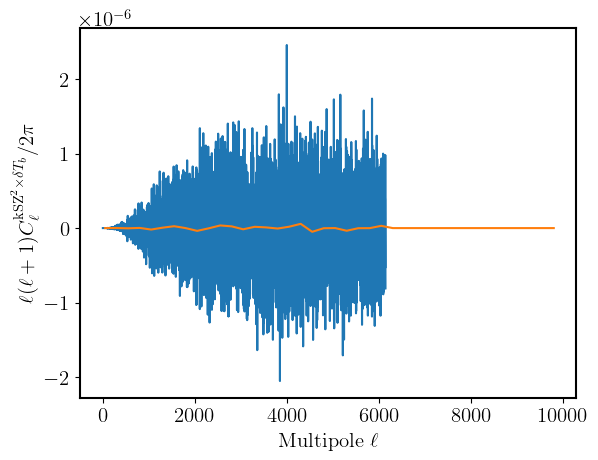

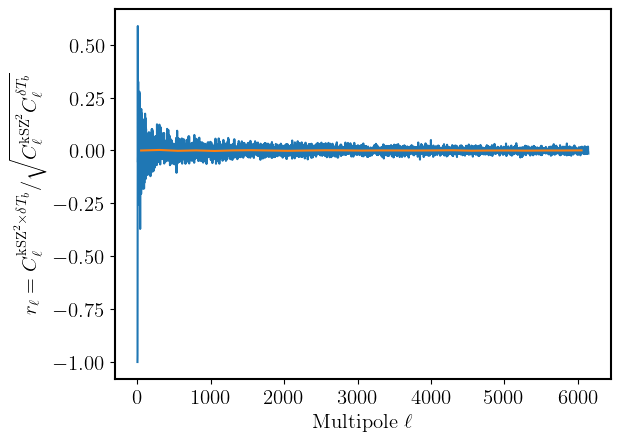

In [53]:
cl_ksz2_21 = hp.anafast(ksz_map**2, dTb_map)
binned_cl_ksz2_21 = bin_spectrum(lrange, cl_ksz2_21, ells_edges)
print(ells, binned_cl_ksz2_21)

plt.figure()
plt.plot(lrange, cl_ksz2_21*lrange*(lrange+1.)/2./np.pi)
plt.plot(ells, binned_cl_ksz2_21*ells*(ells+1.)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\mathrm{kSZ}^2 \times \delta T_b}/2\pi$')
# plt.xlim(0, 2000)

cl_ksz2 = hp.anafast(map1=ksz_map**2)
binned_cl_ksz2 = bin_spectrum(lrange, cl_ksz2, ells_edges,)

plt.figure()
plt.plot(lrange, cl_ksz2_21/np.sqrt(cl_ksz2*p21_cls2))
plt.plot(ells, binned_cl_ksz2_21/np.sqrt(binned_cl_ksz2*binned_cl_ps21))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$r_\ell=C_\ell^{\mathrm{kSZ}^2\times \delta T_b}/\sqrt{C_\ell^{\mathrm{kSZ}^2}C_\ell^{\delta T_b}}$')

#

[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [-6.25409797e-11  3.89109091e-11  7.99233953e-10 -1.95579588e-09
 -1.29096860e-09 -5.84306076e-10  5.61959064e-10  4.42487720e-11
  3.42444747e-10 -4.57132434e-11  7.95564050e-11 -8.24146039e-11
 -5.09213459e-11  3.90208927e-11  5.06849292e-11  1.74680773e-11
  1.89195779e-13 -6.19699843e-12  4.27368643e-12  2.71942104e-11
  2.34095689e-11 -4.54381749e-11  1.22265169e-10 -2.45418783e-11
 -6.51849968e-12  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_26480/2071424087.py:15: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, binned_cl_tau_21/np.sqrt(binned_cl_tau*binned_cl_ps21))


Text(0, 0.5, '$r_\\ell=C_\\ell^{\\delta T_b\\times\\tau}/\\sqrt{C_\\ell^{\\delta T_b}C_\\ell^{\\tau}}$')

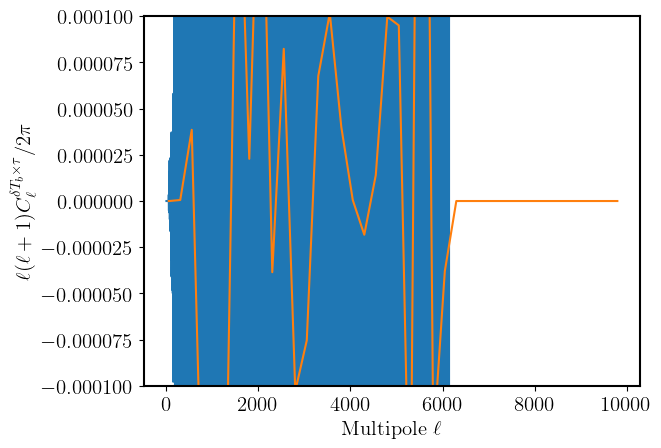

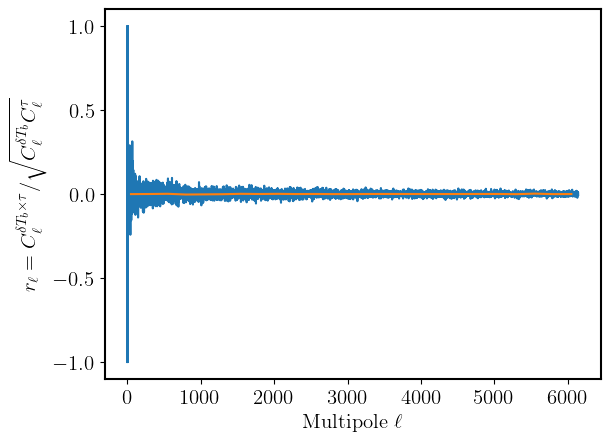

In [54]:
cl_tau_21 = hp.anafast(tau_map, dTb_map)
binned_cl_tau_21 = bin_spectrum(lrange, cl_tau_21, ells_edges)
print(ells, binned_cl_tau_21)

plt.figure()
plt.plot(lrange, cl_tau_21*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, binned_cl_tau_21*ells*(ells+1.)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\delta T_b \times \tau}/2\pi$')
plt.ylim(-1e-4, 1e-4)
# plt.legend(frameon=False)

plt.figure()
plt.plot(lrange, cl_tau_21/np.sqrt(tau_ps2*p21_cls2))
plt.plot(ells, binned_cl_tau_21/np.sqrt(binned_cl_tau*binned_cl_ps21))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$r_\ell=C_\ell^{\delta T_b\times\tau}/\sqrt{C_\ell^{\delta T_b}C_\ell^{\tau}}$')

[  50  300  550  800 1050 1300 1550 1800 2050 2300 2550 2800 3050 3300
 3550 3800 4050 4300 4550 4800 5050 5300 5550 5800 6050 6300 6550 6800
 7050 7300 7550 7800 8050 8300 8550 8800 9050 9300 9550 9800] [ 2.59359853e-08 -2.75883007e-08 -1.48154650e-08 -1.74392634e-08
 -1.23183468e-08 -2.28679471e-08 -8.50884767e-09 -6.08455823e-09
 -9.19501505e-10  2.78198807e-09  5.64114966e-09  3.48706202e-10
  3.56799549e-09 -6.27889172e-10 -3.22276239e-10  1.83185434e-09
 -2.53123377e-09  3.57804144e-10  1.13697361e-09 -1.48316081e-09
  6.09036146e-10  1.26364844e-10  3.67360183e-10  1.27213578e-09
  2.28442918e-10  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


(-3.0, 3.0)

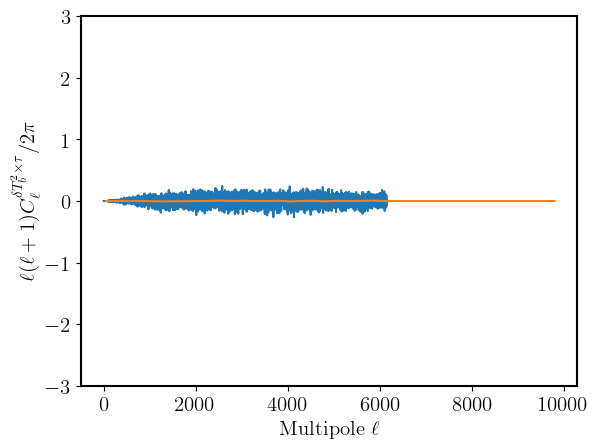

In [55]:
cl_tau_212 = hp.anafast(tau_map, dTb_map**2)
# test = np.arange(0, 5000, step=50)
binned_cl_tau_212 = bin_spectrum(lrange, cl_tau_212, ells_edges)
print(ells, binned_cl_tau_212)

plt.figure()
plt.plot(lrange, cl_tau_212*lrange*(lrange+1)/2./np.pi)
plt.plot(ells, binned_cl_tau_212*ells*(ells+1.)/2./np.pi)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\delta T_b^2 \times \tau}/2\pi$')
plt.ylim(-3., 3.)
# plt.legend(frameon=False)